# **Projet 7 : Implémentez un modèle de scoring**

**Introduction du projet** : 
Vous êtes Data Scientist au sein d'une société financière, nommée "Prêt à dépenser", qui propose des crédits à la consommation pour des personnes ayant peu ou pas du tout d'historique de prêt. L’entreprise souhaite mettre en œuvre un outil de “scoring crédit” pour calculer la probabilité qu’un client rembourse son crédit, puis classifie la demande en crédit accordé ou refusé. Elle souhaite donc développer un algorithme de classification en s’appuyant sur des sources de données variées (données comportementales, données provenant d'autres institutions financières, etc.)

**Mission** :
- Construire un modèle de scoring qui donnera une prédiction sur la probabilité de faillite d'un client de façon automatique.

- Analyser les features qui contribuent le plus au modèle, d’une manière générale (feature importance globale) et au niveau d’un client (feature importance locale), afin, dans un soucis de transparence, de permettre à un chargé d’études de mieux comprendre le score attribué par le modèle.

- Mettre en production le modèle de scoring de prédiction à l’aide d’une API et réaliser une interface de test de cette API.

- Mettre en œuvre une approche globale MLOps de bout en bout, du tracking des expérimentations à l’analyse en production du data drift.

### 📚 **Sommaire**

1. **Description des données**

2. **Analyse exploratoire des données**

    - 2.1. application_train
    - 2.2. application_test
    - 2.3. Distribution de la colonne 'TARGET'
    - 2.4. Type des colonnes

3. **Préparation des données**

    - 3.1. One hot encoding des colonnes catégorielles
    - 3.2. Feature engineering
    - 3.3. Corrélations
    - 3.4. Enregistrement des données
    - 3.5. Métriques d'évaluation / Score métier
    - 3.6. Déséquilibre des classes


### **0. Imports, config et helpers généraux** 

In [ ]:
import os, gc, json, warnings, time, re
from datetime import datetime
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns
import tempfile

# ML de base
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score, make_scorer,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold, KFold, StratifiedShuffleSplit,
    train_test_split, RandomizedSearchCV, learning_curve, validation_curve, cross_val_score
)
from scipy.stats import randint, uniform
from sklearn.base import clone
from sklearn.inspection import permutation_importance

from lightgbm import LGBMClassifier, early_stopping, log_evaluation

import joblib

# XGBoost
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# Imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Suivi expé
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

# Explicabilité
import shap

# Data drift (Evidently)
try:
    from evidently.report import Report
    from evidently.metric_preset import DataDriftPreset
    from evidently.metrics import DatasetDriftMetric, DataDriftTable
    from evidently import ColumnMapping
    HAS_EVIDENTLY = True
except Exception:
    HAS_EVIDENTLY = False

import numpy as np
from sklearn.metrics import confusion_matrix

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
DATA_DIR = "data/raw"

c:\Users\marga\Documents\Openclassrooms\.venv\Lib\site-packages\mlflow\utils\requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251
c:\Users\marga\Documents\Openclassrooms\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("mlflow", mlflow.__version__)

mlflow 2.14.1


In [3]:
# === Helpers ===
def one_hot_encoder(df: pd.DataFrame, nan_as_category: bool = False):
    """One-hot encode des colonnes 'object'.
    Args:
        - df: pd.DataFrame. Dataframe d'entrée
        - nan_as_category: bool. Default False, si True Pandas crée une colonne 'NA' 
        pour indiquer les valeurs manquantes
        
    Returns:
        - df: pd.Dataframe. Le dataframe transformé.
        - new_columns: List. La liste des nouvelles colonnes créées. 
    """
    original_columns = list(df.columns) 
    categorical_columns = [col for col in df.columns if df[col].dtype == 'object']
    df = pd.get_dummies(df, columns=categorical_columns, dummy_na=nan_as_category)
    new_columns = [c for c in df.columns if c not in original_columns]
    return df, new_columns

def cleanup_inf_to_nan(X):
    """Uniformise les données numériques avant imputation.
    Remplace inf/-inf par NaN et force float64 pour l'imputation.
    """
    if isinstance(X, pd.DataFrame):
        X = X.replace([np.inf, -np.inf], np.nan)
        return X.astype(np.float64)
    X = X.astype(np.float64, copy=True)
    X[~np.isfinite(X)] = np.nan
    return X

def compute_business_score(
    y_true,
    y_pred,
    tp_coeff: float = 1.0,
    fp_coeff: float = -10.0,
    fn_coeff: float = -1.0,
    tn_coeff: float = 0.0,
    normalize: bool = False,
    return_breakdown: bool = False,
    threshold: float | None = None,
):
    """
    Calcule le gain métier en pondérant chaque case de matrice de confusion par
    des coefficients métiers :
        - TP (vrai positif) → tp_coeff (par défaut +1)
        - FP (faux positif) → fp_coeff (par défaut −10)
        - FN (faux négatif) → fn_coeff (par défaut −1)
        - TN (vrai négatif) → tn_coeff (par défaut 0)

    Args:
        - y_true: vrais labels (0/1)
        - y_pred: soit binaire (0/1) soit probabilités (si treshold fourni)
        - normalize: bool. Si True, renvoie le gain moyen par observation.
        - return_breakdown: bool. Si True, renvoie aussi le détail TP/FP/FN/TN.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Si des proba sont passées et qu'on fournit un threshold, on binarise
    if threshold is not None:
        y_pred = (y_pred >= threshold).astype(int)

    # Vérifications de base
    if y_true.shape[0] != y_pred.shape[0]:
        raise ValueError("y_true et y_pred doivent avoir la même longueur.")
    # S'assurer que y_pred est bien binaire
    uniques = np.unique(y_pred)
    if not np.all(np.isin(uniques, [0, 1])):
        raise ValueError(
            "y_pred doit être binaire (0/1). "
            "Si tu fournis des probabilités, passe un threshold=..."
        )

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    gain = tp_coeff * tp + fp_coeff * fp + fn_coeff * fn + tn_coeff * tn
    if normalize:
        gain = gain / len(y_true)

    if return_breakdown:
        breakdown = {"TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn)}
        return gain, breakdown
    return gain


def best_threshold_for_business(
        y_true, 
        y_proba,
        tp_coeff=1.0, 
        fp_coeff=-1.0, 
        fn_coeff=-10.0,
        n_points: int = 201
):
    """Cherche un seuil approx. (par quantiles) maximisant le gain métier."""
    qs = np.linspace(0, 1, n_points)
    thr_candidates = np.unique(np.quantile(y_proba, qs))
    best_gain, best_thr = -np.inf, 0.5
    for thr in thr_candidates:
        y_pred = (y_proba >= thr).astype(int) # Binarise
        gain = compute_business_score(y_true, y_pred, tp_coeff, fp_coeff, fn_coeff)
        if gain > best_gain:
            best_gain, best_thr = gain, thr
    return float(best_thr), float(best_gain)

def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
    print ("La table choisie a " + str(df.shape[1]) + " colonnes.\n"      
        + str(mis_val_table_ren_columns.shape[0]) +
          " colonnes ont des valeurs manquantes.")
    return mis_val_table_ren_columns

def is_sampler(step_obj):
    """Détecte un sampler d’imbalanced-learn (objet qui possède un attribut fit_resample)."""
    return hasattr(step_obj, "fit_resample")

def fit_prepro_steps(pre_steps, X_tr, y_tr):
    """
    Enchaîne et fit une liste d’étapes de prétraitement (pre_steps) sur un jeu 
    d’entraînement en gérant deux cas :
    - Samplers imblearn (détectés via is_sampler) → utilisent fit_resample(X, y) 
    et modifient X et y.
    - Transformers sklearn classiques → utilisent fit_transform(X, y) si dispo, 
    sinon fit puis transform (modifie X seulement).
    """
    X_cur, y_cur = X_tr, y_tr
    fitted = []

    for name, step in pre_steps:
        step_f = clone(step)    # on crée un clone neuf

        if is_sampler(step_f):
            # Sampler: on resample en TRAIN
            X_cur, y_cur = step_f.fit_resample(X_cur, y_cur)
            fitted.append((name, step_f))
        else:
            # Transformer classique
            # Si le step supporte fit_transform, on l'utilise
            if hasattr(step_f, "fit_transform"):
                X_cur = step_f.fit_transform(X_cur, y_cur)
            else:
                step_f.fit(X_cur, y_cur)
                X_cur = step_f.transform(X_cur)
            fitted.append((name, step_f))

    return X_cur, y_cur, fitted

def apply_prepro_steps_inference(fitted_steps, X_va):
    """
    Applique, dans l’ordre, les étapes de prétraitement déjà fit (passées via fitted_steps) 
    sur un jeu de validation X_va. Ignore les étapes qui sont des samplers (objets imblearn 
    avec fit_resample) — on ne ré-échantillonne jamais en validation/test.
    """
    X_cur = X_va
    for name, step_f in fitted_steps:
        if is_sampler(step_f):
            # rien à faire en validation
            continue
        # Transformer
        X_cur = step_f.transform(X_cur)
    return X_cur    

def sanitize_feature_names(
    X,
    return_mapping: bool = True,
    empty_name: str = "f_unnamed",
    prefix_digit: str = "f_",
):
    """
    Nettoie les noms de colonnes :
      - remplace [^0-9A-Za-z_] par '_', strip('_')
      - préfixe si commence par un chiffre
      - garantit l'unicité
    Si X n'est pas un DataFrame, renvoie X tel quel.
    """
    if not isinstance(X, pd.DataFrame):
        return X if not return_mapping else (X, {})

    out = X.copy()
    mapping, used = {}, set()

    for c in out.columns.astype(str):
        nc = re.sub(r'[^0-9A-Za-z_]+', '_', c).strip('_')
        if nc and nc[0].isdigit():
            nc = f"{prefix_digit}{nc}"
        if not nc:
            nc = empty_name

        base, i = nc, 1
        while nc in used:
            i += 1
            nc = f"{base}_{i}"
        used.add(nc)
        mapping[c] = nc

    out = out.rename(columns=mapping)
    return (out, mapping) if return_mapping else out

### **1. Description des données** 

Pour la description et l'analyse exploratoire des données nous nous baserons sur le kernel Kaggle suivant : [Start Here: A Gentle Introduction](https://www.kaggle.com/code/willkoehrsen/start-here-a-gentle-introduction/notebook)

Chaque fichier représente une table reliée par un ou plusieurs identifiants :

- application_train / application_test : Données principales des clients actuels, utilisées pour prédire le risque de défaut.
  - Table principale : 1 ligne = 1 prêt en cours
  - Identifiant : `SK_ID_CURR`
  - Colonne `TARGET` : 0 = prêt remboursé / 1 = non remboursé

- bureau : Historique des prêts des clients dans d’autres banques.
  - Chaque ligne = un ancien crédit.
  - Identifiant : `SK_ID_BUREAU`
  - Clé de lien : `SK_ID_CURR`

- bureau_balance : Suivi mois par mois de l’évolution des anciens crédits détenus dans d’autres institutions.
  - Chaque ligne = un mois de suivi d’un ancien crédit.
  - Clé de lien : `SK_ID_BUREAU`

- previous_application : Historique des anciennes demandes de prêt internes à Home Credit.
  - Chaque ligne = une ancienne demande de prêt.
  - Identifiant : `SK_ID_PREV`
  - Clé de lien : `SK_ID_CURR`

- POS_CASH_BALANCE : Historique mensuel des anciens crédits à la consommation chez Home Credit.
  - Chaque ligne = un mois d’un prêt POS ou cash.
  - Clés de lien : `SK_ID_PREV` → `previous_application`

- credit_card_balance : Historique mensuel des balances de cartes de crédit détenues chez Home Credit.
  - Chaque ligne = un mois d’un relevé de carte de crédit.
  - Clés de lien : `SK_ID_PREV` → `previous_application`

- installments_payment : Historique détaillé des paiements effectués ou manqués des anciens prêts Home Credit.
  - Chaque ligne = un paiement réalisé ou manqué.
  - Clés de lien : `SK_ID_PREV` → `previous_application`


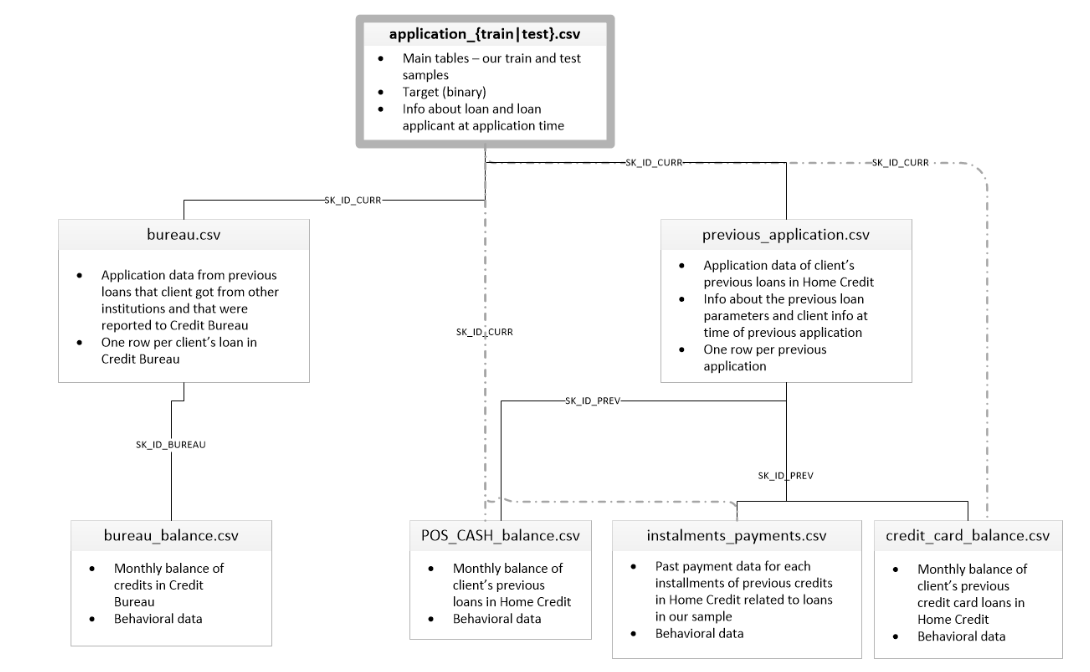

### **2. Analyse exploratoire et préparation des données** 

In [4]:
print(os.listdir("Data/"))

['application_test.csv', 'application_train.csv', 'bureau.csv', 'bureau_balance.csv', 'credit_card_balance.csv', 'df_merged.csv', 'HomeCredit_columns_description.csv', 'installments_payments.csv', 'POS_CASH_balance.csv', 'previous_application.csv', 'sample_submission.csv']


#### **2.1. application_train – chargement + premières vérifications**

In [5]:
app_train = pd.read_csv(os.path.join(DATA_DIR, "application_train.csv"))
print('Training data shape: ', app_train.shape)
app_train.head()

Training data shape:  (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

Les données d'entrainement contiennent 307 511 observations (chacune étant un prêt distinct) et 122 colonnes (variables), y compris la colonne `TARGET` (l'étiquette que nous voulons prédire).

In [6]:
print("Le nombre de doublons dans les données d'entrainement est de : ", 
      app_train[app_train.duplicated()].shape[0])

Le nombre de doublons dans les données d'entrainement est de :  0


In [7]:
# Afficher le taux de remplissage
total_missing_values = app_train.isnull().sum().sum()
taux_de_remplissage = 1 - (total_missing_values / app_train.size)
taux_de_remplissage = taux_de_remplissage*100
print(f"Taux de remplissage : {taux_de_remplissage:.2f}%")

Taux de remplissage : 75.60%


In [8]:
# Statistiques des valeurs manquantes
missing_values = missing_values_table(app_train)
missing_values.head(20)

La table choisie a 122 colonnes.
67 colonnes ont des valeurs manquantes.


,Missing Values,% of Total Values
COMMONAREA_MEDI,214865,69.9
COMMONAREA_AVG,214865,69.9
COMMONAREA_MODE,214865,69.9
NONLIVINGAPARTMENTS_MEDI,213514,69.4
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_MODE,210199,68.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_AVG,210199,68.4


On remarque que 67 colonnes possèdent des valeurs manquantes (avec un taux de remplissage total de 75% environ), nous devrons donc compléter ces valeurs manquantes. Nous pourrons utiliser des modèles tels que LGBM, capables de gérer les valeurs manquantes sans recourir à l'imputation. Une autre option consisterait à supprimer les colonnes présentant un pourcentage élevé de valeurs manquantes, bien qu'il soit impossible de savoir à l'avance si ces colonnes seront utiles à notre modèle. Par conséquent, nous conserverons toutes les colonnes pour l'instant.

#### **2.2. application_test – chargement + premières vérifications**

In [9]:
app_test = pd.read_csv(os.path.join(DATA_DIR, "application_test.csv"))
print('Testing data shape: ', app_test.shape)
app_test.head()

Testing data shape:  (48744, 121)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.018850,-19241,-2329,-5170.0,-812,NaN,1,1,0,1,0,1,NaN,2.0,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.752614,0.789654,0.159520,0.0660,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0505,NaN,NaN,0.0672,0.0612,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0526,NaN,NaN,0.0666,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0514,NaN,NaN,NaN,block of flats,0.0392,"Stone, brick",No,0.0,0.0,0.0,0.0,-1740.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.035792,-18064,-4469,-9118.0,-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.0,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.564990,0.291656,0.432962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,NaN,Working,Higher education,Married,House / apartment,0.019101,-20038,-4458,-2175.0,-3503,5.0,1,1,0,1,0,0,Drivers,2.0,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.699787,0.610991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-856.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,Unaccompanied,Working,Secondary / secondary special,Married

Les données d'entrainement contiennent 48 744 observations (chacune étant un prêt distinct) et 121 colonnes (variables).

In [10]:
print("Le nombre de doublons dans les données de test est de : ", 
      app_test[app_test.duplicated()].shape[0])

Le nombre de doublons dans les données de test est de :  0


In [11]:
# Afficher le taux de remplissage
total_missing_values = app_test.isnull().sum().sum()
taux_de_remplissage = 1 - (total_missing_values / app_test.size)
taux_de_remplissage = taux_de_remplissage*100
print(f"Taux de remplissage : {taux_de_remplissage:.2f}%")

Taux de remplissage : 76.19%


In [12]:
# Statistiques des valeurs manquantes
missing_values = missing_values_table(app_test)
missing_values.head(20)

La table choisie a 121 colonnes.
64 colonnes ont des valeurs manquantes.


,Missing Values,% of Total Values
COMMONAREA_MODE,33495,68.7
COMMONAREA_MEDI,33495,68.7
COMMONAREA_AVG,33495,68.7
NONLIVINGAPARTMENTS_MEDI,33347,68.4
NONLIVINGAPARTMENTS_AVG,33347,68.4
NONLIVINGAPARTMENTS_MODE,33347,68.4
FONDKAPREMONT_MODE,32797,67.3
LIVINGAPARTMENTS_MODE,32780,67.2
LIVINGAPARTMENTS_MEDI,32780,67.2
LIVINGAPARTMENTS_AVG,32780,67.2


De la même manière que pour les données d'entrainement, on remarque que 64 colonnes possèdent des valeurs manquantes (avec un taux de remplissage total de 76% environ), nous devrons donc compléter ces valeurs manquantes. Pour l'instant, nous conserverons toutes les colonnes.

#### **2.3. Distribution de la colonne `TARGET`**

In [13]:
app_train['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

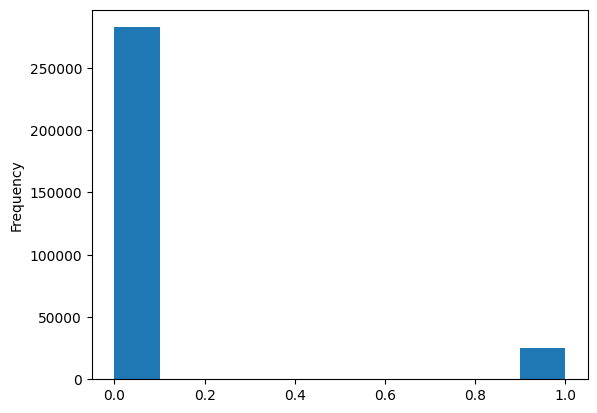

In [14]:
app_train['TARGET'].astype(int).plot.hist()

On remarque que les classes sont déséquilibrées. Les prêts remboursés à temps (TARGET=0) sont bien plus nombreux que ceux non remboursés (TARGET=1). Nous devrons donc pondérer les classes selon leur représentation dans les données afin de refléter ce déséquilibre.

#### **2.4. Typage des colonnes et cardinalité des variables catégorielles**

In [15]:
# Réparition des colonnes pour chaque type
app_train.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

In [16]:
# Nombre de classes uniques dans chaque colonne d'objet
app_train.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64

La plupart des variables catégorielles ont un nombre relativement faible d'entrées uniques. Il nous faudra trouver un moyen de les gérer.

#### **2.5. Détection et marquage des anomalies (DAYS_BIRTH / DAYS_EMPLOYED)**

Un problème que nous devons toujours surveiller lors de l'analyse des données de l'EDA est la présence d'anomalies dans les données. Celles-ci peuvent être dues à des erreurs de saisie, à des erreurs d'équipement de mesure, ou à des mesures valides mais extrêmes. Une façon de justifier quantitativement les anomalies consiste à examiner les statistiques d'une colonne à l'aide de la méthode describe. 

- `DAYS_BIRTH`

In [17]:
app_train['DAYS_BIRTH']

0         -9461
1        -16765
2        -19046
3        -19005
4        -19932
          ...  
307506    -9327
307507   -20775
307508   -14966
307509   -11961
307510   -16856
Name: DAYS_BIRTH, Length: 307511, dtype: int64

Les nombres de la colonne DAYS_BIRTH sont négatifs carils indiquent le nombre de jorus entre la date de naissance du client et la date de sa demande de prêt. 

`DAYS_BIRTH = Date de naissance - Date de la demande`

Pour afficher ces statistiques en années, nous pouvons multiplier par -1 et diviser par le nombre de jours dans une année.

In [18]:
app_train['DAYS_BIRTH'] = -app_train['DAYS_BIRTH']

In [19]:
app_train['AGE'] = app_train['DAYS_BIRTH'] / 365

In [20]:
app_train['AGE'].describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: AGE, dtype: float64

Ces âges semblent raisonnables. Il n'y a pas d'extremes incohérents, la moyenne est aussi plausible.

In [21]:
print("Corr(age,cible):", app_train['AGE'].corr(app_train['TARGET']))

Corr(age,cible): -0.07823930830982698


Interprétation : Une corrélation de −0.07 à −0.08 est quasiment négligeable statistiquement. Les personnes plus âgées ont un peu moins de risque de ne pas rembourser leur crédit, mais l’effet est très faible.

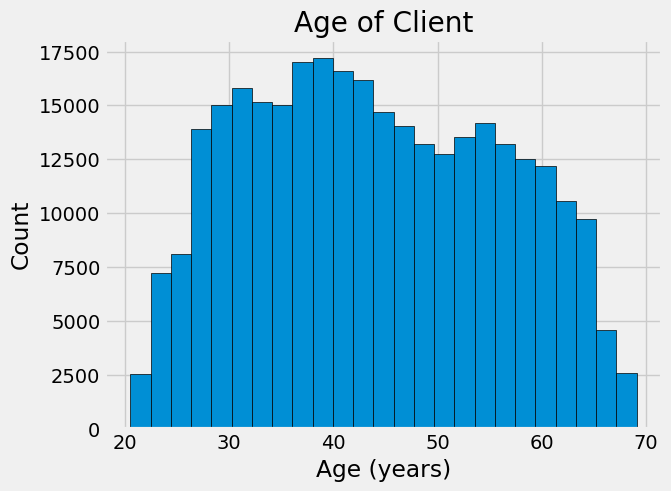

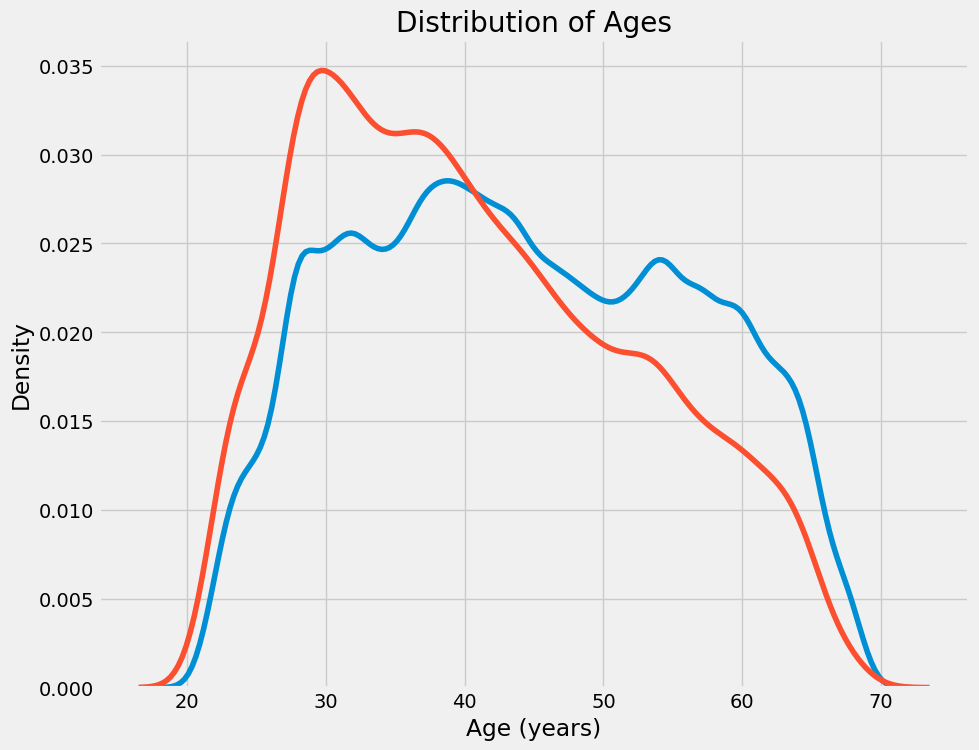

In [22]:
plt.style.use('fivethirtyeight')
plt.hist(app_train['AGE'], edgecolor='k', bins=25)
plt.title('Age of Client'); plt.xlabel('Age (years)'); plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 8))
sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, 'AGE'], label='target == 0')
sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, 'AGE'], label='target == 1')
plt.xlabel('Age (years)'); plt.ylabel('Density'); plt.title('Distribution of Ages')
plt.show()

La courbe bleue (TARGET=0) représente les clients ayant remboursés leur prêt. La densité est plus élevée pour les personnes plus âgées (40-60 ans). Donc, une majorité de bons payeurs se trouvent dans les tranches d'âge plus élevées.

La courbe rouge (TARGET=1) représente les clients ayant eu un défaut de paiement. On observe un pic autour de 25-35 ans, c'est la tranche où les défauts sont les plus fréquents. La densité baisse progressivement avec l'âge. 

DONC les jeunes emprunteurs (20–35 ans) ont un risque de défaut plus élevé et les emprunteurs plus âgés (40–60 ans) sont plus fiables. Cela explique la corrélation légèrement négative (-0.078) : plus l’âge augmente, plus le risque diminue, mais l’effet reste faible (beaucoup d’autres facteurs influencent la cible).

- `DAYS_EMPLOYED`

In [23]:
app_train['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

Cette variable indique le nombre de jours travaillés par le client avant la demande de prêt. Comme pour DAYS_BIRTH, les valeurs sont en jours négatifs parce qu'elles sont comptées par rapport à la date de la demande. 

`DAYS_EMPLOYED = Date d'embauche - Date de la demande`

Ça ne semble pas correct ! La valeur maximale (outre le fait qu'elle soit positive) est d'environ 1 000 ans !

In [24]:
(app_train['DAYS_EMPLOYED'] == 365243).mean()


0.18007160719453938

Environ 18 % des clients ont cette valeur. Il s'agit d'une valeur spéciale indiquant que le client n’a pas ou plus d’emploi (par exemple, retraité, chômeur, etc.)

Text(0.5, 0, 'Days Employment')

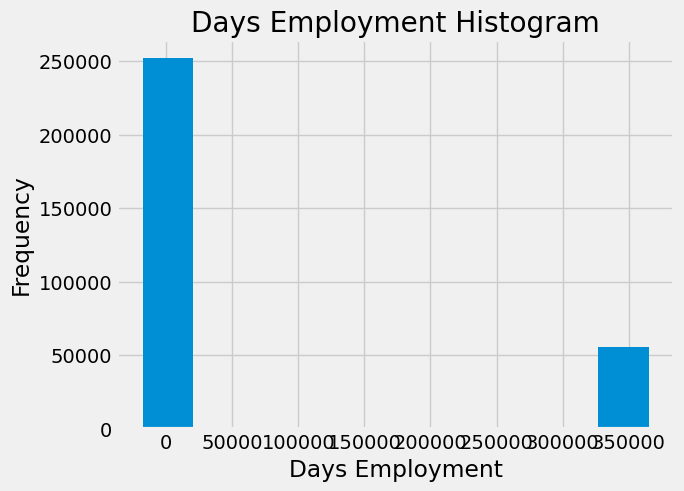

In [25]:
app_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram')
plt.xlabel('Days Employment')

Juste par curiosité, sous-représentons les clients anormaux et voyons s'ils ont tendance à avoir des taux de défaut plus élevés ou plus faibles que le reste des clients.

In [26]:
anom = app_train[app_train['DAYS_EMPLOYED'] == 365243]
non_anom = app_train[app_train['DAYS_EMPLOYED'] != 365243]
print('Les défauts de paiement non anormaux sur %0.2f%% des prêts' % (100 * non_anom['TARGET'].mean()))
print('Les anomalies font défaut sur %0.2f%% des prêts' % (100 * anom['TARGET'].mean()))
print("Il y a %d jours d'emploi anormaux" % len(anom))

Les défauts de paiement non anormaux sur 8.66% des prêts
Les anomalies font défaut sur 5.40% des prêts
Il y a 55374 jours d'emploi anormaux


Voilà qui est extrêmement intéressant ! Il s'avère que les anomalies présentent un taux de défaut plus faible.

La gestion des anomalies dépend de la situation, sans règles prédéfinies. L'une des approches les plus sûres consiste à définir les anomalies avec une valeur manquante, puis à les compléter (par imputation) avant l'apprentissage automatique. Dans ce cas, puisque toutes les anomalies ont exactement la même valeur, nous souhaitons les compléter avec la même valeur au cas où tous ces prêts auraient un point commun. Les valeurs anormales semblent avoir une certaine importance ; nous souhaitons donc indiquer au modèle d'apprentissage automatique si nous les avons effectivement renseignées. Pour résoudre ce problème, nous allons compléter les valeurs anormales avec un nombre (np.nan), puis créer une nouvelle colonne booléenne indiquant si la valeur était anormale ou non.

Text(0.5, 0, 'Days Employment')

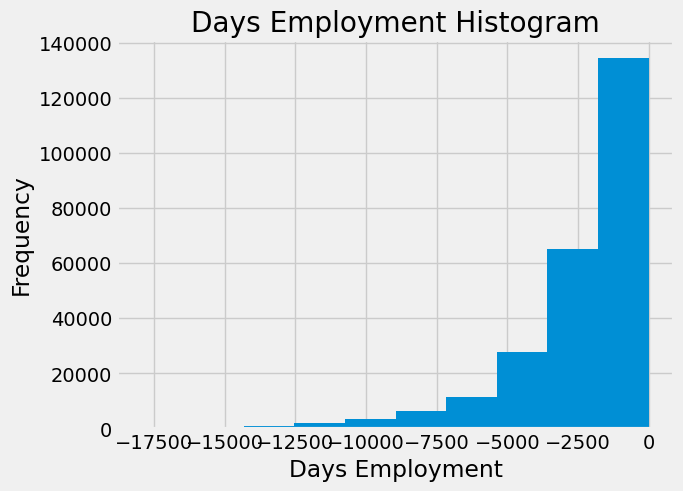

In [27]:
# Create an anomalous flag column
app_train['DAYS_EMPLOYED_ANOM'] = app_train["DAYS_EMPLOYED"] == 365243

# Replace the anomalous values with nan
app_train['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace = True)

app_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram')
plt.xlabel('Days Employment')

La distribution semble beaucoup plus conforme à nos attentes, et nous avons également créé une nouvelle colonne pour indiquer au modèle que ces valeurs étaient initialement anormales (car nous devrons renseigner les valeurs nans avec une valeur, probablement la médiane de la colonne). Les autres colonnes contenant des JOURS dans le dataframe semblent correspondre à nos attentes, sans valeurs aberrantes évidentes.

Il est extrêmement important de noter que toute modification des données d'entraînement doit également être appliquée aux données de test. Nous allons donc créer la nouvelle colonne et renseigner la colonne existante avec np.nan dans les données de test.

In [28]:
app_test['DAYS_EMPLOYED_ANOM'] = app_test["DAYS_EMPLOYED"] == 365243
app_test["DAYS_EMPLOYED"].replace({365243: np.nan}, inplace = True)

print('Il y a %d anomalies dans les données de test sur %d entrées.' % (app_test["DAYS_EMPLOYED_ANOM"].sum(), len(app_test)))

Il y a 9274 anomalies dans les données de test sur 48744 entrées.


#### **2.6. Variable `DAYS_BIRTH` - Effet de l'age sur le remboursement**

In [29]:
app_train['DAYS_BIRTH'] = abs(app_train['DAYS_BIRTH'])
app_train['DAYS_BIRTH'].corr(app_train['TARGET'])

-0.07823930830982709

À mesure que le client vieillit, il existe une relation linéaire négative avec la cible, ce qui signifie qu'avec l'âge, les clients ont tendance à rembourser leurs prêts à temps plus souvent.

Commençons par examiner cette variable. Nous pouvons d'abord créer un histogramme de l'âge. Nous placerons l'axe des abscisses en années pour une meilleure lisibilité du graphique.

Text(0, 0.5, 'Count')

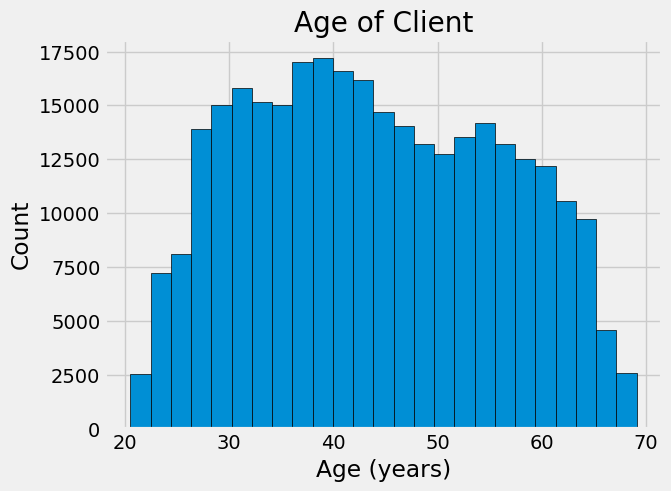

In [30]:
# Set the style of plots
plt.style.use('fivethirtyeight')

# Plot the distribution of ages in years
plt.hist(app_train['DAYS_BIRTH'] / 365, edgecolor = 'k', bins = 25)
plt.title('Age of Client'); plt.xlabel('Age (years)'); plt.ylabel('Count')

En soi, la distribution des âges ne nous apprend pas grand-chose, si ce n'est qu'il n'y a pas de valeurs aberrantes, car tous les âges sont raisonnables. Pour visualiser l'effet de l'âge sur la cible, nous allons maintenant créer un graphique d'estimation de la densité du noyau (KDE) coloré par la valeur de la cible. Un graphique d'estimation de la densité du noyau montre la distribution d'une variable unique et peut être considéré comme un histogramme lissé (il est créé en calculant un noyau, généralement gaussien, à chaque point de données, puis en faisant la moyenne de tous les noyaux individuels pour obtenir une courbe lisse unique). Nous utiliserons le kdeplot de Seaborn pour ce graphique.

Text(0.5, 1.0, 'Distribution of Ages')

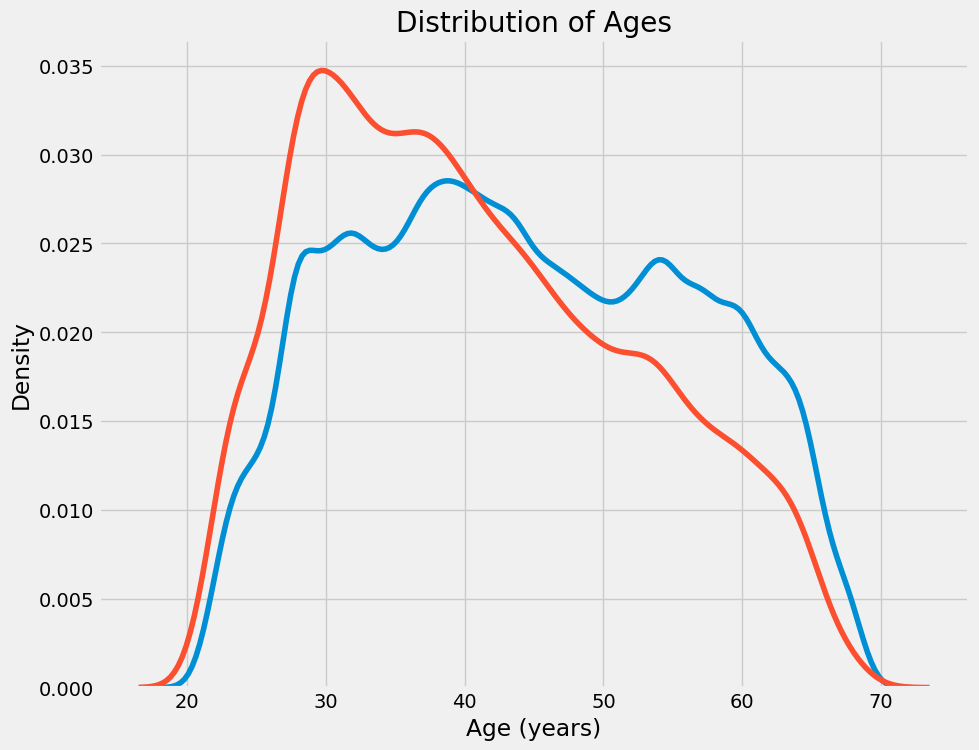

In [31]:
plt.figure(figsize = (10, 8))

# KDE plot of loans that were repaid on time
sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, 'DAYS_BIRTH'] / 365, label = 'target == 0')

# KDE plot of loans which were not repaid on time
sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, 'DAYS_BIRTH'] / 365, label = 'target == 1')

# Labeling of plot
plt.xlabel('Age (years)'); plt.ylabel('Density'); plt.title('Distribution of Ages')

La courbe cible == 1 penche vers les plus jeunes. Bien que cette corrélation ne soit pas significative (coefficient de corrélation de -0,07), cette variable sera probablement utile dans un modèle d'apprentissage automatique, car elle influence la cible. Examinons cette relation sous un autre angle : le taux moyen de non-remboursement des prêts par tranche d'âge.

Pour créer ce graphique, nous découpons d'abord la tranche d'âge en tranches de 5 ans chacune. Ensuite, pour chaque tranche, nous calculons la valeur moyenne de la cible, qui indique le ratio de prêts non remboursés dans chaque tranche d'âge.

In [32]:
# Age information into a separate dataframe
age_data = app_train[['TARGET', 'DAYS_BIRTH']]
age_data['YEARS_BIRTH'] = age_data['DAYS_BIRTH'] / 365

# Bin the age data
age_data['YEARS_BINNED'] = pd.cut(age_data['YEARS_BIRTH'], bins = np.linspace(20, 70, num = 11))
age_data.head(10)

,TARGET,DAYS_BIRTH,YEARS_BIRTH,YEARS_BINNED
0,1,9461,25.920548,"(25.0, 30.0]"
1,0,16765,45.931507,"(45.0, 50.0]"
2,0,19046,52.180822,"(50.0, 55.0]"
3,0,19005,52.068493,"(50.0, 55.0]"
4,0,19932,54.608219,"(50.0, 55.0]"
5,0,16941,46.413699,"(45.0, 50.0]"
6,0,13778,37.747945,"(35.0, 40.0]"
7,0,18850,51.643836,"(50.0, 55.0]"
8,0,20099,55.065753,"(55.0, 60.0]"
9,0,14469,39.641096,"(35.0, 40.0]"


In [33]:
# Group by the bin and calculate averages
age_groups  = age_data.groupby('YEARS_BINNED').mean()
age_groups

,TARGET,DAYS_BIRTH,YEARS_BIRTH
YEARS_BINNED,,,
"(20.0, 25.0]",0.123036,8532.795625,23.377522
"(25.0, 30.0]",0.111436,10155.219250,27.822518
"(30.0, 35.0]",0.102814,11854.848377,32.479037
"(35.0, 40.0]",0.089414,13707.908253,37.555913
"(40.0, 45.0]",0.078491,15497.661233,42.459346
"(45.0, 50.0]",0.074171,17323.900441,47.462741
"(50.0, 55.0]",0.066968,19196.494791,52.593136
"(55.0, 60.0]",0.055314,20984.262742,57.491131
"(60.0, 65.0]",0.052737,22780.547460,62.412459


Text(0.5, 1.0, 'Failure to Repay by Age Group')

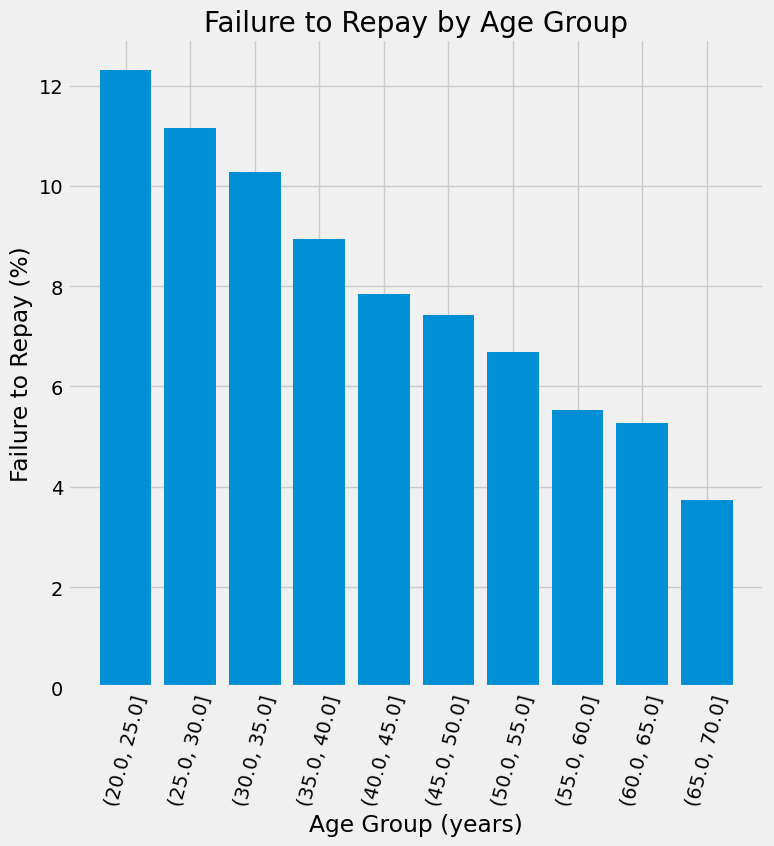

In [34]:
plt.figure(figsize = (8, 8))

# Graph the age bins and the average of the target as a bar plot
plt.bar(age_groups.index.astype(str), 100 * age_groups['TARGET'])

# Plot labeling
plt.xticks(rotation = 75); plt.xlabel('Age Group (years)'); plt.ylabel('Failure to Repay (%)')
plt.title('Failure to Repay by Age Group')

La tendance est claire : les jeunes demandeurs sont plus susceptibles de ne pas rembourser leur prêt ! Le taux de défaut de remboursement est supérieur à 10 % pour les trois tranches d'âge les plus jeunes et inférieur à 5 % pour la tranche d'âge la plus âgée.

Ces informations pourraient être directement utilisées par la banque : les jeunes clients étant moins susceptibles de rembourser leur prêt, il serait peut-être judicieux de leur fournir davantage d'accompagnement ou de conseils en matière de planification financière. Cela ne signifie pas que la banque doive discriminer les jeunes clients, mais qu'il serait judicieux de prendre des mesures préventives pour les aider à rembourser à temps.

#### **2.7. Variables `EXT_SOURCE`**

Ce sont des scores externes de crédit (probablement obtenus via des agences de crédit ou des systèmes internes de notation).

Ils mesurent la fiabilité financière d’un client sur une échelle normalisée entre 0 et 1, où :
- 0 signifie risque élevé (forte probabilité de défaut),
- 1 signifie faible risque (client fiable).

In [35]:
# Extract the EXT_SOURCE variables and show correlations
ext_data = app_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AGE']]
ext_data_corrs = ext_data.corr()
ext_data_corrs

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,AGE
TARGET,1.000000,-0.155317,-0.160472,-0.178919,-0.078239
EXT_SOURCE_1,-0.155317,1.000000,0.213982,0.186846,0.600610
EXT_SOURCE_2,-0.160472,0.213982,1.000000,0.109167,0.091996
EXT_SOURCE_3,-0.178919,0.186846,0.109167,1.000000,0.205478
AGE,-0.078239,0.600610,0.091996,0.205478,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

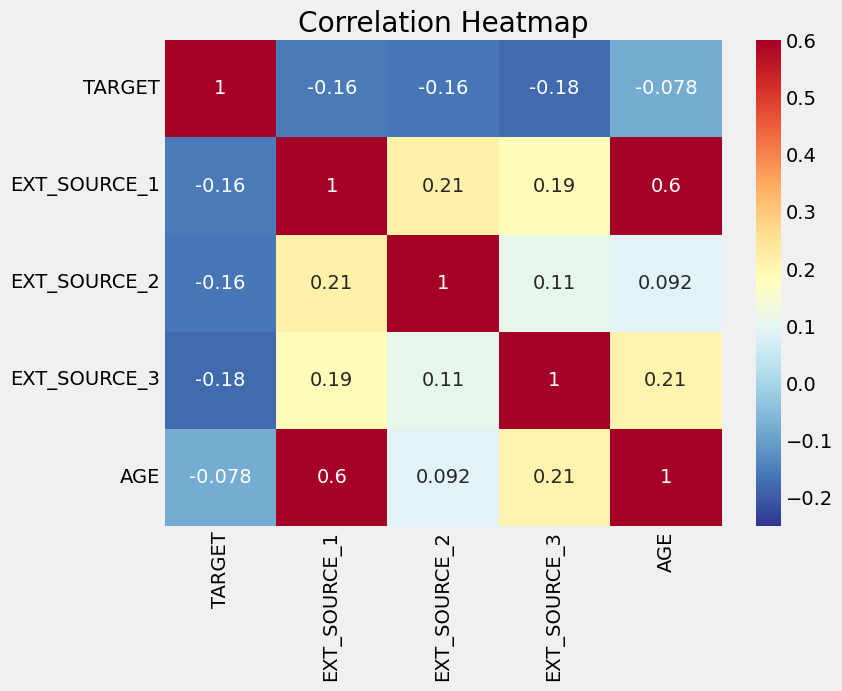

In [36]:
plt.figure(figsize = (8, 6))

# Heatmap of correlations
sns.heatmap(ext_data_corrs, cmap = plt.cm.RdYlBu_r, vmin = -0.25, annot = True, vmax = 0.6)
plt.title('Correlation Heatmap')

Les trois caractéristiques EXT_SOURCE présentent une corrélation négative avec la cible, ce qui indique qu'à mesure que la valeur de EXT_SOURCE augmente, le client est plus susceptible de rembourser son prêt. On constate également que AGE est positivement corrélé à EXT_SOURCE_1, ce qui indique que l'âge du client pourrait être l'un des facteurs de ce score.

Examinons ensuite la distribution de chacune de ces caractéristiques, colorée par la valeur de la cible. Cela nous permettra de visualiser l'effet de cette variable sur la cible.

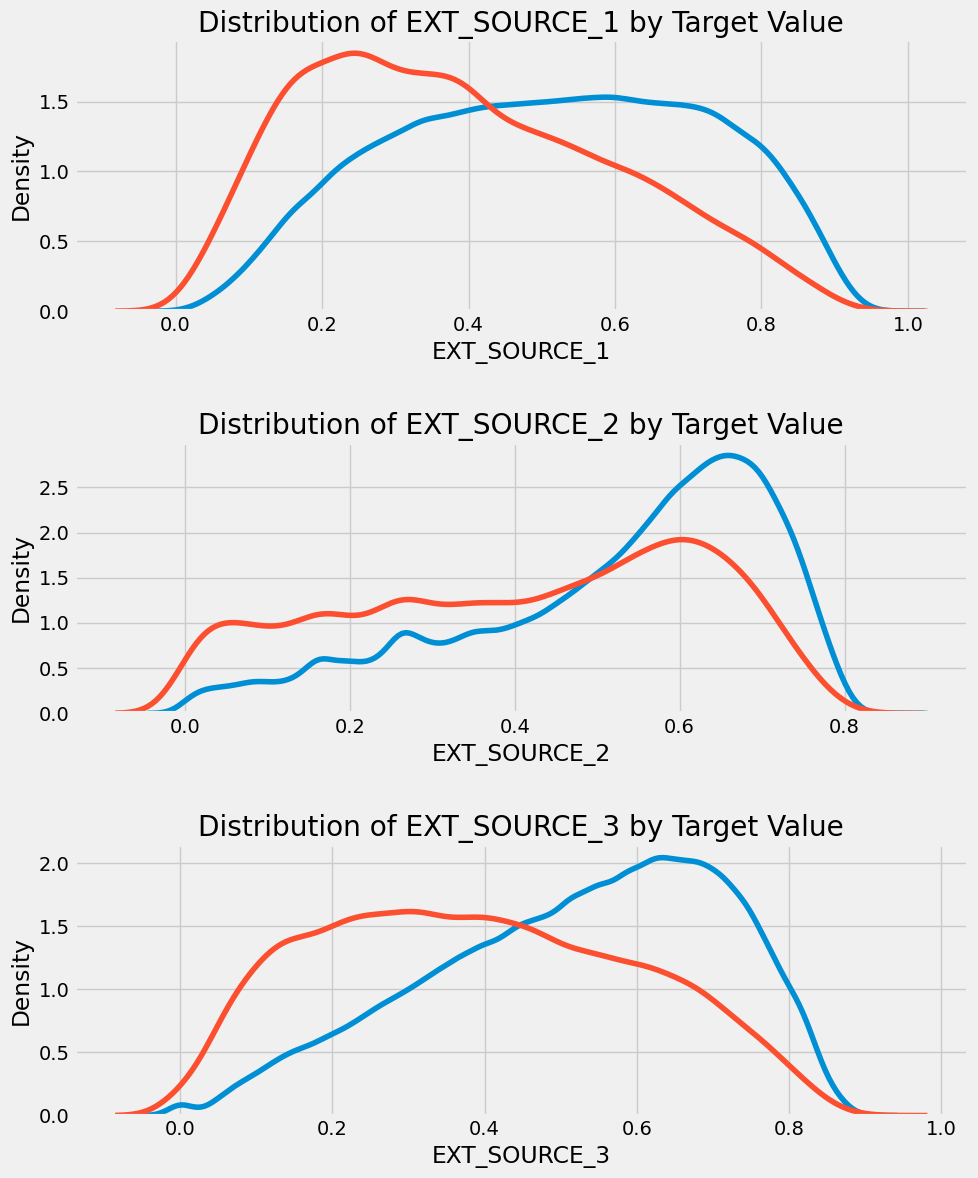

In [37]:
plt.figure(figsize = (10, 12))

# iterate through the sources
for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    
    # create a new subplot for each source
    plt.subplot(3, 1, i + 1)
    # plot repaid loans
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, source], label = 'target == 0')
    # plot loans that were not repaid
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, source], label = 'target == 1')
    
    # Label the plots
    plt.title('Distribution of %s by Target Value' % source)
    plt.xlabel('%s' % source); plt.ylabel('Density')
    
plt.tight_layout(h_pad = 2.5)

La variable EXT_SOURCE_3 présente la plus grande différence entre les valeurs cibles. On constate clairement que cette caractéristique est liée à la probabilité qu'un emprunteur rembourse un prêt. Cette corrélation est faible (en réalité, elles sont toutes considérées comme très faibles, mais ces variables restent utiles à un modèle d'apprentissage automatique pour prédire si un emprunteur remboursera ou non un prêt à temps).

#### **2.8. Variable `OCCUPATION_TYPE`**

Cette variable indique la catégorie socio-professionnelle du demandeur



In [38]:
p1 = (app_train.loc[app_train['TARGET'] == 1, 'OCCUPATION_TYPE']
      .value_counts(normalize=True) * 100)
p0 = (app_train.loc[app_train['TARGET'] == 0, 'OCCUPATION_TYPE']
      .value_counts(normalize=True) * 100)


In [39]:
cats = sorted(set(p0.index).union(p1.index), key=lambda c: p1.get(c, 0), reverse=True)

In [40]:
p1 = p1.reindex(cats).fillna(0)
p0 = p0.reindex(cats).fillna(0)

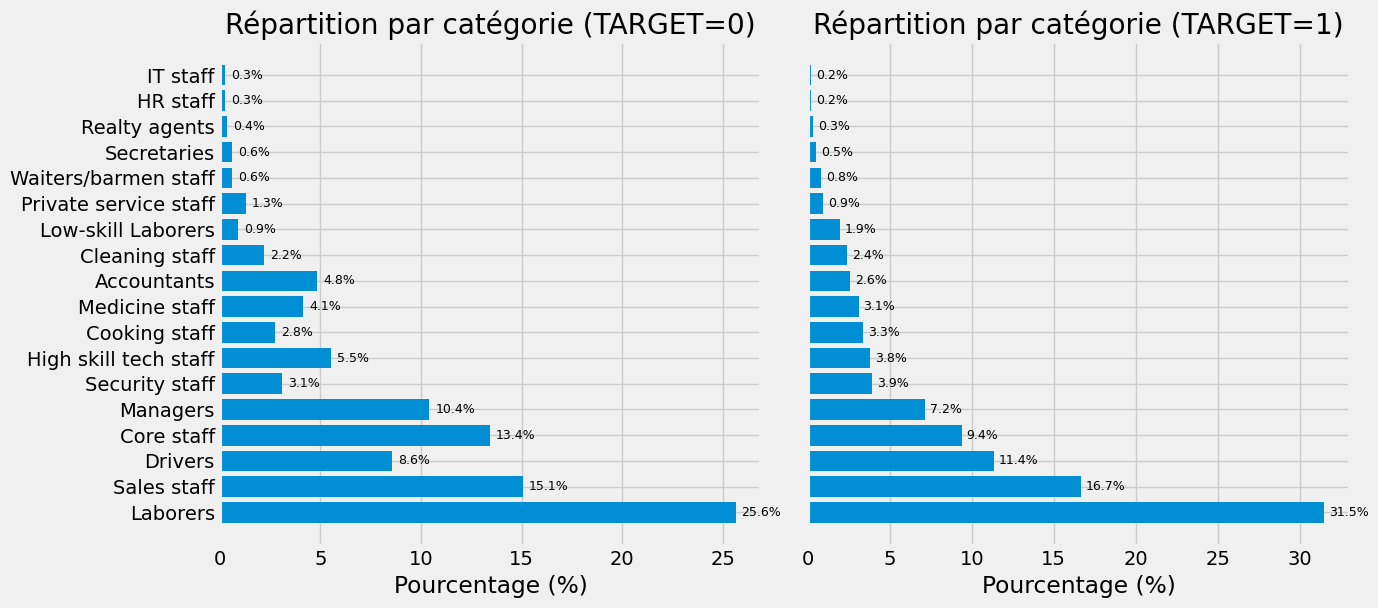

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, max(6, len(cats) * 0.35)), sharey=True)

axes[0].barh(cats, p0.values)
axes[0].set_title("Répartition par catégorie (TARGET=0)")
axes[0].set_xlabel("Pourcentage (%)")
axes[0].invert_yaxis()  # catégorie la plus élevée en haut

axes[1].barh(cats, p1.values)
axes[1].set_title("Répartition par catégorie (TARGET=1)")
axes[1].set_xlabel("Pourcentage (%)")
axes[1].invert_yaxis()

for ax in axes:
    # petites annotations de valeurs au bout des barres
    for y, v in enumerate((p0 if ax is axes[0] else p1).values):
        ax.text(v + 0.3, y, f"{v:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

Le graphique ci-dessus montre la répartition des catégories socioprofessionnelles selon la variable TARGET, qui indique si un client a fait défaut (TARGET = 1) ou non (TARGET = 0).

On observe plusieurs éléments intéressants :
- Les "Laborers" (ouvriers) sont nettement surreprésentés chez les clients en défaut (31.5 %) comparé aux bons payeurs (25.6 %). Cela en fait une catégorie à risque.
- Les "Drivers" (conducteurs) et "Sales staff" (personnels de vente) présentent également une part plus importante parmi les clients ayant fait défaut, ce qui peut traduire une certaine instabilité de revenus dans ces professions.
- À l’inverse, les "Managers", "High skill tech staff" (Personnel technique hautement qualifié) et "Core staff" sont moins représentés chez les clients en défaut, suggérant qu’ils ont des profils plus fiables.

Ces différences indiquent que le métier du client est un facteur pertinent dans l’évaluation du risque de crédit, et cette variable pourrait être utilisée directement (via un encodage) ou indirectement (en créant un score de risque métier).

Pour la préparation des données nous nous baserons sur le kernel Kaggle suivant : [LightGBM with Simple Features](https://www.kaggle.com/code/jsaguiar/lightgbm-with-simple-features/script)

#### **2.9. One hot encoding, FI et merge global**

L'objectif est d'enrichir le jeu de données en construisant un pipeline de FI pour améliorer la capacité prédictive du futur modèle de classification. 

- `application_train.csv` et `application_test.csv`

In [42]:
# Re-load propre pour éviter l’effet de bord EDA
app_train = pd.read_csv(os.path.join(DATA_DIR, "application_train.csv"))
app_test  = pd.read_csv(os.path.join(DATA_DIR, "application_test.csv"))

In [43]:
for df_ in (app_train, app_test):
    df_['DAYS_EMPLOYED_ANOM'] = (df_['DAYS_EMPLOYED'] == 365243)
    df_['DAYS_EMPLOYED'] = df_['DAYS_EMPLOYED'].replace(365243, np.nan)

In [44]:
app_train['AGE'] = (app_train['DAYS_BIRTH'].abs() / 365).astype(float)

In [45]:
nan_as_category = False

print(f"Train : {app_train.shape}, Test : {app_test.shape}")
base = pd.concat([app_train, app_test], axis=0, ignore_index=True)

# Optional: retirer les XNA en genre
if 'CODE_GENDER' in base.columns:
    base = base[base['CODE_GENDER'] != 'XNA']

# Factorize binaires listées (0 ou 1; 2 categories)
for binary_feature in ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'EMERGENCYSTATE_MODE']:
    if binary_feature in base.columns:
        base[binary_feature], _ = pd.factorize(base[binary_feature])

# One-hot des autres catégorielles
base, base_cat_cols = one_hot_encoder(base, nan_as_category=False)

Train : (307511, 124), Test : (48744, 122)


In [46]:
# Étape 1 : Calculer les colonnes non binaires
n_uniques = base.nunique()
not_binary = n_uniques[n_uniques != 2]

# Étape 2 : Retirer les colonnes numériques continues
not_binary_non_numeric = not_binary[~base[not_binary.index].dtypes.isin([np.float64, np.int64])]

# Résultat : colonnes catégorielles non binaires (à vérifier ou encoder différemment)
print(f"{len(not_binary_non_numeric)} colonnes catégorielles non binaires détectées :")

for col in not_binary_non_numeric.index:
    print(col)


75 colonnes catégorielles non binaires détectées :
SK_ID_CURR
CNT_CHILDREN
AMT_INCOME_TOTAL
AMT_CREDIT
AMT_ANNUITY
AMT_GOODS_PRICE
REGION_POPULATION_RELATIVE
DAYS_BIRTH
DAYS_EMPLOYED
DAYS_REGISTRATION
DAYS_ID_PUBLISH
OWN_CAR_AGE
CNT_FAM_MEMBERS
REGION_RATING_CLIENT
REGION_RATING_CLIENT_W_CITY
HOUR_APPR_PROCESS_START
EXT_SOURCE_1
EXT_SOURCE_2
EXT_SOURCE_3
APARTMENTS_AVG
BASEMENTAREA_AVG
YEARS_BEGINEXPLUATATION_AVG
YEARS_BUILD_AVG
COMMONAREA_AVG
ELEVATORS_AVG
ENTRANCES_AVG
FLOORSMAX_AVG
FLOORSMIN_AVG
LANDAREA_AVG
LIVINGAPARTMENTS_AVG
LIVINGAREA_AVG
NONLIVINGAPARTMENTS_AVG
NONLIVINGAREA_AVG
APARTMENTS_MODE
BASEMENTAREA_MODE
YEARS_BEGINEXPLUATATION_MODE
YEARS_BUILD_MODE
COMMONAREA_MODE
ELEVATORS_MODE
ENTRANCES_MODE
FLOORSMAX_MODE
FLOORSMIN_MODE
LANDAREA_MODE
LIVINGAPARTMENTS_MODE
LIVINGAREA_MODE
NONLIVINGAPARTMENTS_MODE
NONLIVINGAREA_MODE
APARTMENTS_MEDI
BASEMENTAREA_MEDI
YEARS_BEGINEXPLUATATION_MEDI
YEARS_BUILD_MEDI
COMMONAREA_MEDI
ELEVATORS_MEDI
ENTRANCES_MEDI
FLOORSMAX_MEDI
FLOORSMIN_ME

In [47]:
# Ratios simples (Application)
if {'DAYS_EMPLOYED','DAYS_BIRTH'}.issubset(base.columns):
    base['DAYS_EMPLOYED_PERC'] = base['DAYS_EMPLOYED'] / base['DAYS_BIRTH']
if {'AMT_INCOME_TOTAL','AMT_CREDIT'}.issubset(base.columns):
    base['INCOME_CREDIT_PERC'] = base['AMT_INCOME_TOTAL'] / base['AMT_CREDIT']
if {'AMT_INCOME_TOTAL','CNT_FAM_MEMBERS'}.issubset(base.columns):
    base['INCOME_PER_PERSON'] = base['AMT_INCOME_TOTAL'] / base['CNT_FAM_MEMBERS']
if {'AMT_ANNUITY','AMT_INCOME_TOTAL'}.issubset(base.columns):
    base['ANNUITY_INCOME_PERC'] = base['AMT_ANNUITY'] / base['AMT_INCOME_TOTAL']
if {'AMT_ANNUITY','AMT_CREDIT'}.issubset(base.columns):
    base['PAYMENT_RATE'] = base['AMT_ANNUITY'] / base['AMT_CREDIT']

- Chargement des autres tables secondaires + agrégations

Ces fichiers décrivent l’historique de crédit externe du client (hors Home Credit).

Objectif : déduire des comportements de crédit passés, par ex. combien de crédits actifs ? Durée moyenne ? Montant dû ? Score de stabilité…

In [48]:
# --- Bureau / Bureau_balance ---
bureau = pd.read_csv(os.path.join(DATA_DIR, "bureau.csv"))
bureau_balance = pd.read_csv(os.path.join(DATA_DIR, "bureau_balance.csv"))

bureau_balance, bureau_balance_cat = one_hot_encoder(bureau_balance, nan_as_category=True)
bureau, bureau_cat = one_hot_encoder(bureau, nan_as_category=True)

In [49]:
# Agrégations bureau_balance → bureau
bureau_balance_agg = bureau_balance.groupby('SK_ID_BUREAU').agg({
    'MONTHS_BALANCE': ['min', 'max', 'size'],
    **{c: ['mean'] for c in bureau_balance_cat}
})
bureau_balance_agg.columns = pd.Index([f"{a}_{b.upper()}" for a, b in bureau_balance_agg.columns])
bureau = bureau.join(bureau_balance_agg, on='SK_ID_BUREAU', how='left').drop(columns=['SK_ID_BUREAU'])


In [50]:
# Agrégations finales bureau par SK_ID_CURR
num_aggs = {
    'DAYS_CREDIT': ['min', 'max', 'mean', 'var'],
    'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],
    'DAYS_CREDIT_UPDATE': ['mean'],
    'CREDIT_DAY_OVERDUE': ['max', 'mean'],
    'AMT_CREDIT_MAX_OVERDUE': ['mean'],
    'AMT_CREDIT_SUM': ['max', 'mean', 'sum'],
    'AMT_CREDIT_SUM_DEBT': ['max', 'mean', 'sum'],
    'AMT_CREDIT_SUM_OVERDUE': ['mean'],
    'AMT_CREDIT_SUM_LIMIT': ['mean', 'sum'],
    'AMT_ANNUITY': ['max', 'mean'],
    'CNT_CREDIT_PROLONG': ['sum'],
    'MONTHS_BALANCE_MIN': ['min'],
    'MONTHS_BALANCE_MAX': ['max'],
    'MONTHS_BALANCE_SIZE': ['mean', 'sum']
}
cat_aggs = {c: ['mean'] for c in bureau_cat}
cat_aggs.update({f"{c}_MEAN": ['mean'] for c in bureau_balance_cat})

bureau_agg = bureau.groupby('SK_ID_CURR').agg({**num_aggs, **cat_aggs})
bureau_agg.columns = pd.Index([f"BURO_{a}_{b.upper()}" for a, b in bureau_agg.columns])

# Active / Closed
if 'CREDIT_ACTIVE_Active' in bureau.columns:
    active = bureau[bureau['CREDIT_ACTIVE_Active'] == 1]
    active_agg = active.groupby('SK_ID_CURR').agg(num_aggs)
    active_agg.columns = pd.Index([f"ACTIVE_{a}_{b.upper()}" for a, b in active_agg.columns])
    bureau_agg = bureau_agg.join(active_agg, how='left')

if 'CREDIT_ACTIVE_Closed' in bureau.columns:
    closed = bureau[bureau['CREDIT_ACTIVE_Closed'] == 1]
    closed_agg = closed.groupby('SK_ID_CURR').agg(num_aggs)
    closed_agg.columns = pd.Index([f"CLOSED_{a}_{b.upper()}" for a, b in closed_agg.columns])
    bureau_agg = bureau_agg.join(closed_agg, how='left')

Previous_application contient les anciennes demandes de prêt chez Home Credit.

Objectif : capturer l’historique de relation client avec l'organisme : combien de demandes ? Acceptées/refusées ? Montants ? Délais ?

In [51]:
# --- Previous ---
prev = pd.read_csv(os.path.join(DATA_DIR, "previous_application.csv"))
for c in ['DAYS_FIRST_DRAWING','DAYS_FIRST_DUE','DAYS_LAST_DUE_1ST_VERSION','DAYS_LAST_DUE','DAYS_TERMINATION']:
    if c in prev.columns:
        prev[c] = prev[c].replace(365243, np.nan)

if {'AMT_APPLICATION','AMT_CREDIT'}.issubset(prev.columns):
    prev['APP_CREDIT_PERC'] = prev['AMT_APPLICATION'] / prev['AMT_CREDIT']

prev, prev_cat_cols = one_hot_encoder(prev, nan_as_category=True)
num_aggs_prev = {
    'AMT_ANNUITY': ['min','max','mean'],
    'AMT_APPLICATION': ['min','max','mean'],
    'AMT_CREDIT': ['min','max','mean'],
    'APP_CREDIT_PERC': ['min','max','mean','var'],
    'AMT_DOWN_PAYMENT': ['min','max','mean'],
    'AMT_GOODS_PRICE': ['min','max','mean'],
    'HOUR_APPR_PROCESS_START': ['min','max','mean'],
    'RATE_DOWN_PAYMENT': ['min','max','mean'],
    'DAYS_DECISION': ['min','max','mean'],
    'CNT_PAYMENT': ['mean','sum'],
}
cat_aggs_prev = {c: ['mean'] for c in prev_cat_cols}
prev_agg = prev.groupby('SK_ID_CURR').agg({**num_aggs_prev, **cat_aggs_prev})
prev_agg.columns = pd.Index([f"PREV_{a}_{b.upper()}" for a, b in prev_agg.columns])

if 'NAME_CONTRACT_STATUS_Approved' in prev.columns:
    approved = prev[prev['NAME_CONTRACT_STATUS_Approved'] == 1]
    app_agg = approved.groupby('SK_ID_CURR').agg(num_aggs_prev)
    app_agg.columns = pd.Index([f"APPROVED_{a}_{b.upper()}" for a, b in app_agg.columns])
    prev_agg = prev_agg.join(app_agg, how='left')

if 'NAME_CONTRACT_STATUS_Refused' in prev.columns:
    refused = prev[prev['NAME_CONTRACT_STATUS_Refused'] == 1]
    ref_agg = refused.groupby('SK_ID_CURR').agg(num_aggs_prev)
    ref_agg.columns = pd.Index([f"REFUSED_{a}_{b.upper()}" for a, b in ref_agg.columns])
    prev_agg = prev_agg.join(ref_agg, how='left')

POS_CASH_balance suit l’évolution des contrats actifs (type prêt ou crédit renouvelable).

Objectif : voir la stabilité et ponctualité du client dans le suivi de ses échéances.

In [52]:
# --- POS_CASH ---
pos = pd.read_csv(os.path.join(DATA_DIR, "POS_CASH_balance.csv"))
pos, pos_cat_cols = one_hot_encoder(pos, nan_as_category=True)
aggs_pos = {'MONTHS_BALANCE':['max','mean','size'], 'SK_DPD':['max','mean'], 'SK_DPD_DEF':['max','mean']}
aggs_pos.update({c:['mean'] for c in pos_cat_cols})
pos_agg = pos.groupby('SK_ID_CURR').agg(aggs_pos)
pos_agg.columns = pd.Index([f"POS_{a}_{b.upper()}" for a, b in pos_agg.columns])
pos_agg['POS_COUNT'] = pos.groupby('SK_ID_CURR').size()

Installments Payments liste les paiements d’échéances pour les anciens prêts.

Objectif : détecter les retards chroniques, paiements partiels, comportements atypiques.

In [53]:
# --- Installments ---
ins = pd.read_csv(os.path.join(DATA_DIR, "installments_payments.csv"))
ins['PAYMENT_PERC'] = ins['AMT_PAYMENT'] / ins['AMT_INSTALMENT']
ins['PAYMENT_DIFF'] = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']
ins['DPD'] = (ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']).clip(lower=0)
ins['DBD'] = (ins['DAYS_INSTALMENT'] - ins['DAYS_ENTRY_PAYMENT']).clip(lower=0)
aggs_ins = {
    'NUM_INSTALMENT_VERSION':['nunique'],
    'DPD':['max','mean','sum'],
    'DBD':['max','mean','sum'],
    'PAYMENT_PERC':['max','mean','sum','var'],
    'PAYMENT_DIFF':['max','mean','sum','var'],
    'AMT_INSTALMENT':['max','mean','sum'],
    'AMT_PAYMENT':['min','max','mean','sum'],
    'DAYS_ENTRY_PAYMENT':['max','mean','sum']
}
ins, ins_cat_cols = one_hot_encoder(ins, nan_as_category=True)
aggs_ins.update({c:['mean'] for c in ins_cat_cols})
ins_agg = ins.groupby('SK_ID_CURR').agg(aggs_ins)
ins_agg.columns = pd.Index([f"INSTAL_{a}_{b.upper()}" for a, b in ins_agg.columns])
ins_agg['INSTAL_COUNT'] = ins.groupby('SK_ID_CURR').size()

Credit Card Balance représente l'historique de l’utilisation des cartes de crédit.

Objectif : estimer le niveau d’endettement via cartes, fréquence d’utilisation, comportement de paiement.

In [54]:
# --- Credit Card ---
cc = pd.read_csv(os.path.join(DATA_DIR, "credit_card_balance.csv"))
cc, cc_cat_cols = one_hot_encoder(cc, nan_as_category=True)
if 'SK_ID_PREV' in cc.columns:
    cc = cc.drop(columns=['SK_ID_PREV'])
cc_agg = cc.groupby('SK_ID_CURR').agg(['min','max','mean','sum','var'])
cc_agg.columns = pd.Index([f"CC_{a}_{b.upper()}" for a, b in cc_agg.columns])
cc_agg['CC_COUNT'] = cc.groupby('SK_ID_CURR').size()

- Merge

In [55]:
# --- Merge global ---
df = base.copy()
for left in (bureau_agg, prev_agg, pos_agg, ins_agg, cc_agg):
    df = df.join(left, on='SK_ID_CURR', how='left')

In [56]:
print("df merged shape:", df.shape)

df merged shape: (356251, 797)


In [57]:
df.to_csv(os.path.join(DATA_DIR, 'df_merged.csv'), index=False)

#### **2.10. Split train/test et drop colonnes**

In [58]:
# On conserve TARGET tel qu'il est (présent uniquement pour le segment train)
is_train = df['TARGET'].notna()
train_df = df.loc[is_train].reset_index(drop=True)
test_df  = df.loc[~is_train].reset_index(drop=True)

In [59]:
# Drop colonnes très incomplètes (seuil 60%)
missing_pct = train_df.isnull().mean() * 100  # calcul sur train uniquement
cols_drop = missing_pct[missing_pct > 60].index.tolist()
print(f"Colonnes drop (>60% NaN): {len(cols_drop)}")

Colonnes drop (>60% NaN): 212


In [60]:
train_df = train_df.drop(columns=cols_drop)
test_df  = test_df.drop(columns=cols_drop)
print("Train after drop:", train_df.shape, "Test after drop:", test_df.shape)

Train after drop: (307507, 585) Test after drop: (48744, 585)


#### **2.11. Evaluation générique en CV (AUC/AP/Gain) pour Pipelines**

Déséquilibre des coûts métier et fonction de gain

Il existe un **déséquilibre de coûts** entre :
- **Faux positif (FP)** : La banque prête de l'argent à quelqu’un qui ne remboursera pas → Perte du capital prêté + Pas de marge + Éventuels frais de recouvrement
- **Faux négatif (FN)** : La banque ne prête pas à quelqu’un qui aurait remboursé → Perte de la marge potentielle + Perte d’un bon client (peut aller chez la concurrence) MAIS Pas de perte de capital

Hypothèse : le **coût d’un FP est 10×** celui d’un FN.

--

Fonction de gain (positif = valeur créée, négatif = perte)

- **Vrais positifs (TP)** – bons clients correctement acceptés : **+1**
- **Faux positifs (FP)** – mauvais clients acceptés : **−10**
- **Faux négatifs (FN)** – bons clients refusés à tort : **−1**
- **Vrais négatifs (TN)** – mauvais clients correctement refusés : **0** (neutre)

Formule : Gain total = 1xTP − 1xFP − 10xFN
(Les TN sont ignorés.)

> **Note :** ces pondérations peuvent être **ajustées** selon les retours métier, le portefeuille, la conjoncture et le comportement observé à l’entraînement et en production (ex. calibration des seuils).


Petit test pour illustrer l’impact métier d’une erreur de prédiction sur un petit jeu de fausses données : 

In [61]:
# --- Jeu de données simple et parfaitement bien prédit ---
# 1 = bon client, 0 = mauvais client
y_true = np.array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0])  # 5 bons, 5 mauvais
y_pred_perfect = y_true.copy()                     # prédictions parfaites

# --- Coefficients métier réalistes ---
# +1 : gain si bon client accepté
# -10 : perte si mauvais client accepté
# -1 : perte d’opportunité si bon client refusé
#  0 : neutre si mauvais client refusé
tp_coeff, fp_coeff, fn_coeff, tn_coeff = 1, -10, -1, 0

# --- Gain de base (parfait) ---
base_gain, base_break = compute_business_score(
    y_true, y_pred_perfect,
    tp_coeff=tp_coeff, fp_coeff=fp_coeff, fn_coeff=fn_coeff, tn_coeff=tn_coeff,
    return_breakdown=True
)
base_TP, base_FP, base_FN, base_TN = base_break["TP"], base_break["FP"], base_break["FN"], base_break["TN"]

# --- Scénario 1 : introduire 1 faux positif (accepter un mauvais client) ---
y_pred_fp = y_pred_perfect.copy()
idx_fp = np.where(y_true == 0)[0][0]  # prendre un "mauvais client"
y_pred_fp[idx_fp] = 1                 # le modèle l'accepte à tort
gain_fp, br_fp = compute_business_score(
    y_true, y_pred_fp,
    tp_coeff=tp_coeff, fp_coeff=fp_coeff, fn_coeff=fn_coeff, tn_coeff=tn_coeff,
    return_breakdown=True
)

# --- Scénario 2 : introduire 1 faux négatif (refuser un bon client) ---
y_pred_fn = y_pred_perfect.copy()
idx_fn = np.where(y_true == 1)[0][0]  # prendre un "bon client"
y_pred_fn[idx_fn] = 0                 # le modèle le refuse à tort
gain_fn, br_fn = compute_business_score(
    y_true, y_pred_fn,
    tp_coeff=tp_coeff, fp_coeff=fp_coeff, fn_coeff=fn_coeff, tn_coeff=tn_coeff,
    return_breakdown=True
)

# --- Récapitulatif ---
df_test = pd.DataFrame([
    {
        "Scenario": "Parfait (référence)",
        "TP": base_TP, "FP": base_FP, "FN": base_FN, "TN": base_TN,
        "Gain": base_gain, "Δ vs base": 0
    },
    {
        "Scenario": "Ajouter 1 faux positif (accepter un mauvais client)",
        "TP": br_fp["TP"], "FP": br_fp["FP"], "FN": br_fp["FN"], "TN": br_fp["TN"],
        "Gain": gain_fp, "Δ vs base": gain_fp - base_gain
    },
    {
        "Scenario": "Ajouter 1 faux négatif (refuser un bon client)",
        "TP": br_fn["TP"], "FP": br_fn["FP"], "FN": br_fn["FN"], "TN": br_fn["TN"],
        "Gain": gain_fn, "Δ vs base": gain_fn - base_gain
    },
])

print(df_test.to_string(index=False))


                                           Scenario  TP  FP  FN  TN  Gain  Δ vs base
                                Parfait (référence)   5   0   0   5     5          0
Ajouter 1 faux positif (accepter un mauvais client)   5   1   0   4    -5        -10
     Ajouter 1 faux négatif (refuser un bon client)   4   0   1   5     3         -2


On voit bien que le gain diminue fortement en présence d'un faux positif, et un peu moins en présence d'un faux négatif.

In [62]:
# X/y (numériques+bool uniquement)
y = train_df["TARGET"].astype(int).values
X = train_df.drop(columns=["TARGET"]).select_dtypes(include=[np.number, "bool"]).copy()

Créons une fonction qui construit une pipeline complète de classification LightGBM, intégrant du nettoyage de données, de l'imputation et l'entrainement du modèle lui-même.

Pour rappel le LightGBM est un algorithme d'ensemble basé sur des arbres de décision, entrainés de manière séquentielle pour corriger les erreurs des arbres précédents.

In [63]:
def make_lgbm_pipeline(impute_strategy: str):
    return Pipeline(steps=[
        ("cleanup",  FunctionTransformer(cleanup_inf_to_nan, validate=False)),  # light GBM ne gère pas les infinis
        ("sanitize", FunctionTransformer(sanitize_feature_names, kw_args={"return_mapping": False}, validate=False)),
        ("imputer",  SimpleImputer(strategy=("most_frequent" if impute_strategy=="mode" else impute_strategy))), # Gère les valeurs NaN
        ("lgbm",     LGBMClassifier(
            n_estimators=5000,  # nb max d'arbres à entrainer
            learning_rate=0.03, # taux d'apprentissage
            num_leaves=48,      # nombre max de feuilles par arbre
            subsample=0.8,      # fraction de données utilisée à chaque itération
            colsample_bytree=0.8,   # fraction de colonens sélectionnées aléatoirement à chaque arbre
            max_depth=-1,       # profondeur max des arbres; -1 signifie aucune limite
            min_child_samples=50,   # nombre minimum d'exemples dans une feuille
            n_jobs=-1,
            random_state=42,
            force_col_wise=True
        ))
    ])


Kit overfitting

In [64]:
def eval_holdout_overfit(pipeline, X_df, y_arr, test_size=0.2, random_state=42):
    """
    Split stratifié, fit, compare AUC/AP train vs valid, et retourne un rapport + flags.
    """
    assert isinstance(X_df, pd.DataFrame), "X doit être un DataFrame (pour .iloc)."
    sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    (tr_idx, va_idx), = sss.split(X_df, y_arr)
    X_tr, X_va = X_df.iloc[tr_idx], X_df.iloc[va_idx]
    y_tr, y_va = y_arr[tr_idx], y_arr[va_idx]

    pipeline_fit = clone(pipeline)
    pipeline_fit.fit(X_tr, y_tr)

    p_tr = pipeline_fit.predict_proba(X_tr)[:, 1]
    p_va = pipeline_fit.predict_proba(X_va)[:, 1]

    auc_tr = roc_auc_score(y_tr, p_tr); auc_va = roc_auc_score(y_va, p_va)
    ap_tr  = average_precision_score(y_tr, p_tr); ap_va = average_precision_score(y_va, p_va)

    gap_auc = auc_tr - auc_va
    gap_ap  = ap_tr - ap_va

    flags = []
    if gap_auc > 0.03: flags.append(f"Train–Valid AUC gap {gap_auc:.3f} (>0.03)")
    if auc_tr > 0.90 and auc_va < 0.80: flags.append("Très grande marge Train>>Valid")
    if gap_ap > 0.05: flags.append("Train–Valid AP gap > 0.05 (classes déséquilibrées)")
    # NB: AUC > 0.82 n’est pas un critère d’overfit en soi ; on regarde l’écart et la stabilité.

    report = pd.Series({
        "AUC_train": auc_tr, "AUC_valid": auc_va, "AUC_gap": gap_auc,
        "AP_train": ap_tr,   "AP_valid": ap_va,   "AP_gap":  gap_ap
    })
    return report, flags

def cv_auc_stability(pipeline, X_df, y_arr, n_splits=5, random_state=42):
    """Scores AUC en CV avec moyenne/écart-type/min/max pour juger la stabilité."""
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = cross_val_score(pipeline, X_df, y_arr, scoring="roc_auc", cv=cv, n_jobs=-1)
    return pd.Series({
        "CV_AUC_mean": scores.mean(),
        "CV_AUC_std":  scores.std(),
        "CV_AUC_min":  scores.min(),
        "CV_AUC_max":  scores.max()
    })

def plot_learning_curves(estimator, X_df, y_arr, cv_splits=5,
                         train_sizes=np.linspace(0.1, 1.0, 6), scoring="roc_auc"):
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    sizes, train_scores, val_scores = learning_curve(
        estimator, X_df, y_arr, cv=cv, train_sizes=train_sizes,
        scoring=scoring, n_jobs=-1, shuffle=True, random_state=42
    )
    tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    va_mean, va_std = val_scores.mean(axis=1),  val_scores.std(axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(sizes, tr_mean, marker="o", label="Train")
    plt.fill_between(sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.2)
    plt.plot(sizes, va_mean, marker="o", label="Validation")
    plt.fill_between(sizes, va_mean-va_std, va_mean+va_std, alpha=0.2)
    plt.xlabel("Taille d'entraînement"); plt.ylabel(scoring.upper()); plt.title("Learning Curves")
    plt.legend(); plt.grid(True); plt.show()

def plot_validation_curve_complexity(pipeline, X_df, y_arr,
                                     param_name="lgbm__num_leaves",
                                     param_range=(8, 16, 24, 32, 48, 64),
                                     cv_splits=5, scoring="roc_auc"):
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    train_scores, val_scores = validation_curve(
        pipeline, X_df, y_arr, param_name=param_name, param_range=param_range,
        scoring=scoring, cv=cv, n_jobs=-1
    )
    tr_mean, va_mean = train_scores.mean(axis=1), val_scores.mean(axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(param_range, tr_mean, marker="o", label="Train")
    plt.plot(param_range, va_mean, marker="o", label="Validation")
    plt.xlabel(param_name); plt.ylabel(scoring.upper()); plt.title("Validation Curve")
    plt.legend(); plt.grid(True); plt.show()

def target_shuffle_auc(pipeline, X_df, y_arr, n_splits=3, random_state=42):
    """Test anti-fuite: on permute y; l’AUC CV doit tomber ≈ 0.5."""
    rng = np.random.RandomState(random_state)
    y_perm = pd.Series(y_arr).sample(frac=1.0, random_state=rng).to_numpy()
    return cv_auc_stability(pipeline, X_df, y_perm, n_splits=n_splits, random_state=random_state)

def quick_permutation_importance(pipeline, X_df, y_arr, random_state=42):
    """Importance par permutation sur split holdout (stabilité indicative)."""
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=random_state)
    (tr, va), = sss.split(X_df, y_arr)
    X_tr, X_va = X_df.iloc[tr], X_df.iloc[va]
    y_tr, y_va = y_arr[tr], y_arr[va]
    pipe = clone(pipeline).fit(X_tr, y_tr)
    r = permutation_importance(pipe, X_va, y_va, scoring="roc_auc",
                               n_repeats=5, random_state=random_state, n_jobs=-1)
    return pd.Series(r.importances_mean, index=X_df.columns).sort_values(ascending=False)

Définissons une fonction pour évaluer notre pipeline LightGBM à présent, qui contient le préprocessing, éventuellement du resampling et le tout via cross-validation. 

In [65]:
def evaluate_cv(
        model,  # pipeline complet → preprocessing + classifier
        X,      # features (variables explicatives)
        y,      # target
        name: str, # nom du modèle pour l'affichage
        cv=None,    # plan de cross-validation
        tp_coeff=1.0, 
        fp_coeff=-10.0, 
        fn_coeff=-1.0):
    """
    Évalue un (Imb)Pipeline en CV :
      - En TRAIN : applique prépro + samplers (fit_resample)
      - En VALIDATION : applique uniquement les transforms (jamais de resampling)
      - Entraîne LGBM directement sur X_transf déjà prêt (plus d'`eval_set` brut)
    """
    if cv is None:
        # utilisation de la classe de scikit-learn qui permet de faire de la CV stratifiée
        # les folds sont stratifiés selon la variable cible y → par exemple, on a 8% de TARGET = 1 dans 
        # le jeu de données, donc chaque fold en aura aussi ~8%
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 

    # Vérifie que model est bien un pipeline sklearn.Pipeline et qu'il contient au moins 1 étape
    assert hasattr(model, "steps") and len(model.steps) >= 1, "Il faut un pipeline avec au moins 1 étape."
    # Sépare le pipeline en (prépro) et (lgbm final)
    pre_steps = model.steps[:-1]        # on isole les étapes de préprocessing
    lgbm = clone(model.steps[-1][1])    # on extrait le modèle final, ici LGBMClassifier
    # on crée une copie propre du modèle, avec les mêmes hyperparamètres, mais sans les poids entraînés !

    # Cree un dictionnaire pour stocker les résultats de chaque fold
    metrics_accu = defaultdict(list)    
    
    # Boucle principale de CV
    for fold, (tr, va) in enumerate(cv.split(X, y), 1):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        y_tr, y_va = y[tr], y[va]

        # 1) Fit + transform (et resample si SMOTE) sur TRAIN
        X_tr_t, y_tr_t, fitted_steps = fit_prepro_steps(pre_steps, X_tr, y_tr)

        # 2) Transform ONLY (sans resample) sur VALIDATION
        X_va_t = apply_prepro_steps_inference(fitted_steps, X_va)

        # 3) Fit LGBM directement sur les matrices transformées
        lgbm_fit = clone(lgbm)
        # petite sécurité pour jeux larges/sparses
        try:
            lgbm_fit.set_params(force_col_wise=True) # force l'entrainement col par col
        except Exception:
            pass
        
        # Apprentissage du modèle sur les données transformées
        lgbm_fit.fit(
            X_tr_t, y_tr_t,
            eval_set=[(X_va_t, y_va)],
            eval_metric="auc",
            callbacks=[early_stopping(200), log_evaluation(period=0)]
        )

        proba_va = lgbm_fit.predict_proba(X_va_t)[:, 1] # proba de classe 1

        # Evaluation
        auc = roc_auc_score(y_va, proba_va) # aire sous la courbe ROC
        ap  = average_precision_score(y_va, proba_va)   # aire sous la courbe PR
        thr, gain_best = best_threshold_for_business(y_va, proba_va, tp_coeff, fp_coeff, fn_coeff) # seuil qui maximise le gain métier
        gain_05 = compute_business_score(y_va, (proba_va >= 0.5).astype(int), tp_coeff, fp_coeff, fn_coeff) # gain métier si on utilise un seuil fixe de 0.5

        # On enregistre les métriques pour ce fold
        metrics_accu["fold"].append(fold)
        metrics_accu["auc_roc"].append(auc)
        metrics_accu["ap_pr"].append(ap)
        metrics_accu["best_thr"].append(thr)
        metrics_accu["gain@best_thr"].append(gain_best)
        metrics_accu["gain@0.5"].append(gain_05)

        # Affiche un résumé pour chaque fold
        print(f"[{name}] Fold {fold}: AUC={auc:.4f} | AP={ap:.4f} | gain@best={gain_best:.1f} | thr={thr:.3f}")

    out = pd.DataFrame(metrics_accu)
    print(f"\n==== {name} (moyennes) ====")
    print(out.mean(numeric_only=True).to_frame("mean").T.round(4))
    return out


**Métriques enregistrées a chaque fold de CV** 

| Nom de la métrique | Description                                                                                                                                                                                                     |
| ------------------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `fold`             | Numéro du fold (de 1 à *k*) dans la **cross-validation stratifiée**.                                                                                                                                            |
| `auc_roc`          | Aire sous la courbe ROC (AUC). Mesure la capacité du modèle à **discriminer** les classes (0 = bon payeur, 1 = mauvais payeur), quelle que soit la probabilité seuil. <br>🔹 Valeur entre 0 et 1 (1 = parfait). |
| `ap_pr`            | Moyenne de la précision sur la courbe de rappel (Average Precision, **AP**). Représente la **qualité du classement** des prédictions positives. <br>🔹 Utile pour les **datasets déséquilibrés**.               |
| `best_thr`         | Seuil de probabilité **optimisé** pour **maximiser le gain métier** (`compute_business_score`). C’est ce seuil qui sépare 0 et 1 pour générer les prédictions finales.                                          |
| `gain@best_thr`    | Gain métier obtenu en appliquant le **meilleur seuil** trouvé sur ce fold. <br>🔸 Prend en compte les coefficients TP / FP / FN définis métier.                                                                 |
| `gain@0.5`         | Gain métier obtenu avec un **seuil standard de 0.5**, pour comparer avec le seuil optimisé.                                                                                                                     |


In [66]:
results = {}
# 3 stratégies d'imputation
for strat in ["mean", "median", "mode"]:
    pipe = make_lgbm_pipeline(strat)
    print(f"\n### Évaluation LGBM + imputer='{strat}'")
    res = evaluate_cv(pipe, X, y, name=f"LGBM+{strat}")
    results[strat] = res.mean(numeric_only=True)


### Évaluation LGBM + imputer='mean'
[LightGBM] [Info] Number of positive: 19860, number of negative: 226145
[LightGBM] [Info] Total Bins 62380
[LightGBM] [Info] Number of data points in the train set: 246005, number of used features: 550
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[906]	valid_0's auc: 0.782751	valid_0's binary_logloss: 0.238219
[LGBM+mean] Fold 1: AUC=0.7828 | AP=0.2785 | gain@best=-4975.0 | thr=0.911
[LightGBM] [Info] Number of positive: 19860, number of negative: 226145
[LightGBM] [Info] Total Bins 62499
[LightGBM] [Info] Number of data points in the train set: 246005, number of used features: 551
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469
Training until validation scores don't improve for 20

In [67]:
summary = (pd.DataFrame(results)
           .T[['auc_roc','ap_pr','gain@best_thr','best_thr','gain@0.5']]
           .sort_values('auc_roc', ascending=False))
print("\nComparaison des stratégies d'imputation (moyennes CV) :")
display(summary)


Comparaison des stratégies d'imputation (moyennes CV) :


,auc_roc,ap_pr,gain@best_thr,best_thr,gain@0.5
mode,0.787414,0.280270,-4963.0,0.857055,-6308.6
median,0.787291,0.280447,-4965.4,0.863196,-6233.0
mean,0.786606,0.278811,-4965.4,0.858813,-6330.6


In [68]:
best_impute = summary.index[0]
print("➡️ Stratégie d'imputation retenue :", best_impute)

➡️ Stratégie d'imputation retenue : mode


**Interprétation** :

- **Performance globale (AUC ROC & AP PR)** : très proches entre les trois méthodes, avec un léger avantage pour `mode`.
- **Gain au seuil optimal** : tous les modèles sont déficitaires (gains négatifs), mais `mode` reste le plus performant.
- **Seuil optimal (`best_thr`)** : `median` ajuste le seuil plus haut pour probablement limiter les faux positifs.
- **Gain au seuil fixe 0.5** : `median` obtient le **meilleur résultat** (plus faible perte).

Conclusion :

> Les trois stratégies sont globalement équivalentes en performance.  
> Le choix dépendra donc du contexte d’usage :
> - Si on optimise dynamiquement le seuil : `mode` est légèrement supérieur.
> - Si on fixe le seuil à 0.5 en production : `median` limite mieux les pertes.


#### **2.12. Comparaison déséquilibre des classes : baseline vs SMOTE vs scale_pos_weight**

##### **2.12.1. Analyse de la situation**

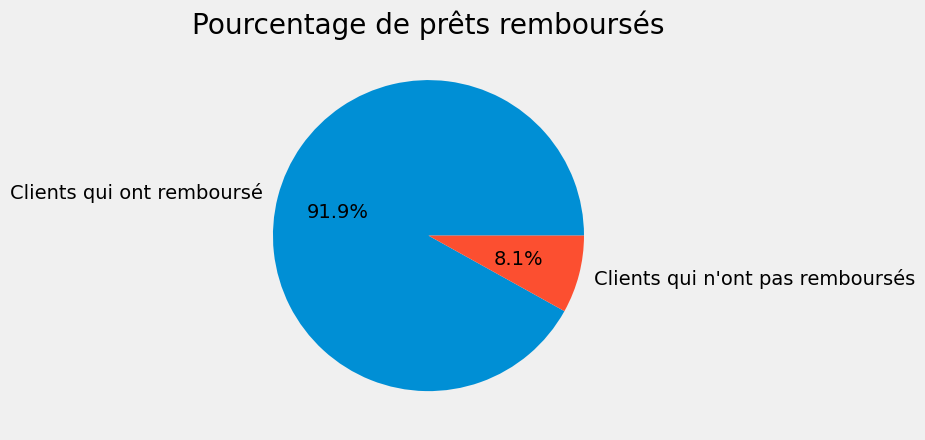

In [69]:
fig = plt.figure()
# Calculate the percentage of each class and plot it into a pie
plt.pie(train_df["TARGET"].value_counts()/train_df.shape[0]*100,
        autopct='%1.1f%%',
        labels=["Clients qui ont remboursé", "Clients qui n'ont pas remboursés"]
       )
plt.title('Pourcentage de prêts remboursés')
plt.show()

Le jeu de données présente une **forte disproportion entre les deux classes cibles** :

- `TARGET = 0` : clients qui **ont remboursé** leur prêt → **91.9 %**
- `TARGET = 1` : clients qui **n'ont pas remboursé** leur prêt → **8.1 %**

La difficulté de travailler avec des jeux de données déséquilibrés réside dans le fait que la plupart des techniques d'apprentissage automatique ignorent la classe minoritaire et, par conséquent, produisent de faibles performances sur celle-ci, alors que c'est généralement cette performance qui est la plus importante.

Nous allons comparer plusieurs approches pour gérer ce déséquilibre :

- **Baseline** (aucune stratégie particulière)
- **SMOTE** (oversampling synthétique de la classe minoritaire)
- **`scale_pos_weight`** (pondération intégrée dans LightGBM)

Le but est de déterminer laquelle **améliore le mieux la détection des clients à risque**, tout en conservant de bonnes performances globales.

##### **2.12.2. Modèle de référence - Baseline**

In [70]:
# Baseline (reutilise best_impute)
baseline = make_lgbm_pipeline(best_impute)
baseline_results = evaluate_cv(baseline, X, y, name=f"Baseline (imputer={best_impute})")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226145
[LightGBM] [Info] Total Bins 62190
[LightGBM] [Info] Number of data points in the train set: 246005, number of used features: 535
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[771]	valid_0's auc: 0.783735	valid_0's binary_logloss: 0.237904
[Baseline (imputer=mode)] Fold 1: AUC=0.7837 | AP=0.2795 | gain@best=-4963.0 | thr=0.884
[LightGBM] [Info] Number of positive: 19860, number of negative: 226145
[LightGBM] [Info] Total Bins 62316
[LightGBM] [Info] Number of data points in the train set: 246005, number of used features: 535
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469
Training until validation scores don't improve for 200 rounds
Early stopping,

##### **2.12.3. Modèle avec gestion du déséquilibre via scale_pos_weight**

LightGBM permet de gérer le déséquilibre directement dans l’apprentissage grâce au paramètre `scale_pos_weight`. Ce dernier ajuste le poids de la classe minoritaire dans la fonction de perte pour lui donner plus d’importance. Il est généralement défini comme : `scale_pos_weight = nb_classes_majoritaires / nb_classes_minoritaires`, ce qui évite de modifier les données d’entraînement.

In [71]:
# Calcul du rapport entre le nombre de classes majoritaires (0) et les classes minoritaires (1)
ratio = (y==0).sum() / max((y==1).sum(), 1)

# Limites du ratio : min=1 (pour pas sous pondérer la classe positive) et max=12 (pour pas donner une importance excessive a cette classe)
spw = min(max(ratio, 1.0), 12.0)

# Création du pipeline
spw_pipe = Pipeline(steps=[
    ("cleanup", FunctionTransformer(cleanup_inf_to_nan, validate=False)),
    ("imputer", SimpleImputer(strategy=("most_frequent" if best_impute=="mode" else best_impute))),
    ("lgbm", LGBMClassifier(
        n_estimators=5000, 
        learning_rate=0.03, 
        num_leaves=48,
        subsample=0.8, 
        colsample_bytree=0.8, 
        max_depth=-1,
        min_child_samples=50, 
        n_jobs=-1, 
        random_state=42, 
        force_col_wise=True,
        scale_pos_weight=spw    # pondère les erreurs sur les classes déséquilibrées : donne plus d’importance à la classe minoritaire
    ))
])

spw_results = evaluate_cv(spw_pipe, X, y, name=f"LGBM scale_pos_weight={spw:.1f}")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226145
[LightGBM] [Info] Total Bins 62190
[LightGBM] [Info] Number of data points in the train set: 246005, number of used features: 535
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[2]	valid_0's auc: 0.706335	valid_0's binary_logloss: 0.278517
[LGBM scale_pos_weight=11.4] Fold 1: AUC=0.7063 | AP=0.1812 | gain@best=-5649.0 | thr=0.128
[LightGBM] [Info] Number of positive: 19860, number of negative: 226145
[LightGBM] [Info] Total Bins 62316
[LightGBM] [Info] Number of data points in the train set: 246005, number of used features: 535
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469
Training until validation scores don't improve for 200 rounds
Early stopping

##### **2.12.4. Modèle avec gestion du déséquilibre via SMOTE**

Une approche pour gérer les jeux de données déséquilibrés consiste à suréchantillonner la classe minoritaire. La méthode la plus simple consiste à dupliquer des exemples dans la classe minoritaire, bien que ces exemples n'apportent aucune information nouvelle au modèle. De nouveaux exemples peuvent être synthétisés à partir des exemples existants. Il s'agit d'une forme d'augmentation des données pour la classe minoritaire, appelée technique de suréchantillonnage synthétique des minorités, ou SMOTE.

In [72]:
# SMOTE (via imblearn Pipeline)
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
smote_pipe = ImbPipeline(steps=[
    ("cleanup", FunctionTransformer(cleanup_inf_to_nan, validate=False)),
    ("imputer", SimpleImputer(strategy=("most_frequent" if best_impute=="mode" else best_impute))),
    ("smote", SMOTE(
        sampling_strategy=0.3, # le nombre de positifs devient 30% du nombre de négatifs
        k_neighbors=5, # pour chaque point minoritaire, SMOTE en crée un nouveau à partir de 5 voisins proches
        random_state=42
        )
    ),
    ("lgbm", LGBMClassifier(
        n_estimators=3000, 
        learning_rate=0.03, 
        num_leaves=48,
        subsample=0.8, 
        colsample_bytree=0.8, 
        n_jobs=-1, 
        random_state=42, 
        force_col_wise=True
    ))
])
smote_results = evaluate_cv(smote_pipe, X, y, name="SMOTE + LGBM", cv=cv3)

[LightGBM] [Info] Number of positive: 56536, number of negative: 188454
[LightGBM] [Info] Total Bins 119561
[LightGBM] [Info] Number of data points in the train set: 244990, number of used features: 546
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.230769 -> initscore=-1.203976
[LightGBM] [Info] Start training from score -1.203976
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[900]	valid_0's auc: 0.785329	valid_0's binary_logloss: 0.237476
[SMOTE + LGBM] Fold 1: AUC=0.7853 | AP=0.2811 | gain@best=-8273.0 | thr=0.900
[LightGBM] [Info] Number of positive: 56536, number of negative: 188455
[LightGBM] [Info] Total Bins 120166
[LightGBM] [Info] Number of data points in the train set: 244991, number of used features: 547
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.230768 -> initscore=-1.203982
[LightGBM] [Info] Start training from score -1.203982
Training until validation scores don't improve for 200 rounds
Early stopping, best ite

In [73]:
summary = pd.DataFrame({
    "Baseline":       baseline_results.mean(numeric_only=True),
    "scale_pos_weight": spw_results.mean(numeric_only=True),
    "SMOTE":          smote_results.mean(numeric_only=True)
})

In [74]:
summary = summary.T.round(4)
display(summary)

,fold,auc_roc,ap_pr,best_thr,gain@best_thr,gain@0.5
Baseline,3.0,0.7874,0.2803,0.8571,-4963.0,-6308.6000
scale_pos_weight,3.0,0.7077,0.1808,0.1278,-5693.0,-4965.0000
SMOTE,2.0,0.7850,0.2770,0.8779,-8273.0,-10448.3333


- Le modèle Baseline donne les meilleurs scores AUC et AP ainsi que le meilleur gain au seuil optimal.

- La méthode scale_pos_weight réussit à améliorer le gain à seuil fixe (0.5), ce qui peut être utile si le seuil ne peut pas être adapté (ex. cas en production). Mais elle dégrade clairement les performances globales (auc_roc, ap_pr, gain@best_thr).

- Le modèle SMOTE obtient de bonnes performances en auc_roc et ap_pr, mais son gain est fortement dégradé. Cela peut être dû à une généralisation plus difficile ou à une mauvaise calibration des probabilités générées.

In [75]:
results = []

for ratio in [0.1, 0.2, 0.3, 0.4]:
    for k in [3, 5, 7]:
        print(f"SMOTE sampling={ratio}, k={k}")
        smote_pipe = ImbPipeline(steps=[
            ("cleanup", FunctionTransformer(cleanup_inf_to_nan, validate=False)),
            ("imputer", SimpleImputer(strategy=("most_frequent" if best_impute=="mode" else best_impute))),
            ("smote", SMOTE(
                sampling_strategy=ratio, 
                k_neighbors=k, 
                random_state=42)),
            ("lgbm", LGBMClassifier(
                n_estimators=3000, 
                learning_rate=0.03, 
                num_leaves=48,
                subsample=0.8, 
                colsample_bytree=0.8,
                n_jobs=-1, 
                random_state=42, 
                force_col_wise=True
            ))
        ])
        smote_results_2 = evaluate_cv(smote_pipe, X, y, name=f"SMOTE r={ratio} k={k}", cv=cv3)

        smote_results_2["sampling_strategy"] = ratio
        smote_results_2["k_neighbors"] = k
        
        results.append(smote_results_2)

SMOTE sampling=0.1, k=3
[LightGBM] [Info] Number of positive: 18845, number of negative: 188454
[LightGBM] [Info] Total Bins 86487
[LightGBM] [Info] Number of data points in the train set: 207299, number of used features: 540
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090907 -> initscore=-2.302606
[LightGBM] [Info] Start training from score -2.302606
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[855]	valid_0's auc: 0.785691	valid_0's binary_logloss: 0.237381
[SMOTE r=0.1 k=3] Fold 1: AUC=0.7857 | AP=0.2825 | gain@best=-8285.0 | thr=0.880
[LightGBM] [Info] Number of positive: 18845, number of negative: 188455
[LightGBM] [Info] Total Bins 86964
[LightGBM] [Info] Number of data points in the train set: 207300, number of used features: 541
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090907 -> initscore=-2.302612
[LightGBM] [Info] Start training from score -2.302612
Training until validation scores don't improve for 200 rounds

In [76]:
res = pd.concat(results, ignore_index=True)

k_neighbors,3,5,7
sampling_strategy,,,
0.1,-8277.0,-8281.0,-8273.0
0.2,-8273.0,-8273.0,-8273.0
0.3,-8277.0,-8273.0,-8277.0
0.4,-8273.0,-8277.0,-8273.0


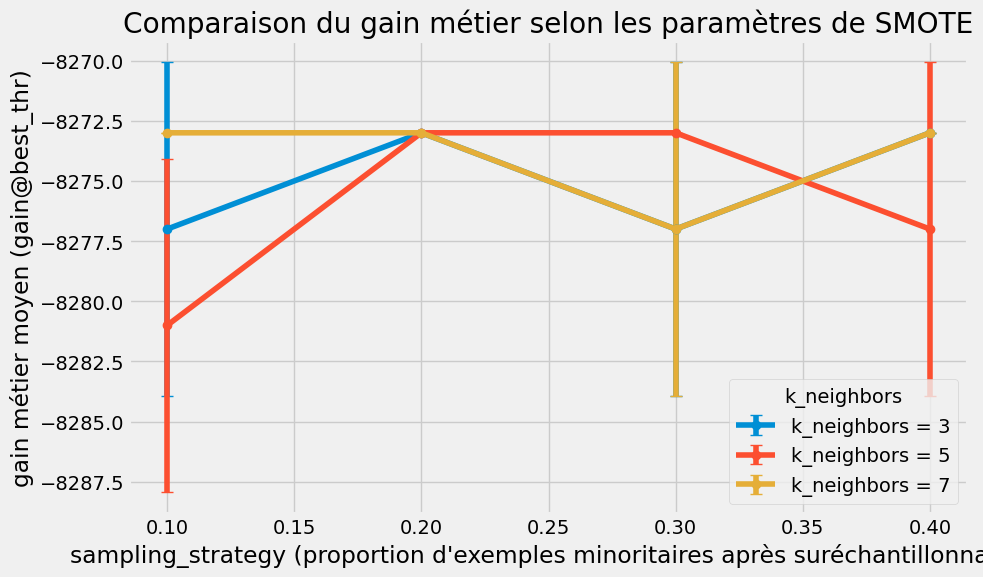

[TOP gain@best_thr]     {'sampling_strategy': 0.2, 'k_neighbors': 3.0, 'gain_mean': -8273.0, 'gain_std': 0.0, 'auc_mean': 0.7849425851276086, 'ap_mean': 0.2768865638695556, 'n': 3.0}
[TOP AUC ROC moyen]     {'sampling_strategy': 0.1, 'k_neighbors': 5.0, 'gain_mean': -8281.0, 'gain_std': 6.928203230275509, 'auc_mean': 0.7854961125931378, 'ap_mean': 0.2781950221889627, 'n': 3.0}
[TOP AP (AUC-PR) moy.]  {'sampling_strategy': 0.1, 'k_neighbors': 7.0, 'gain_mean': -8273.0, 'gain_std': 0.0, 'auc_mean': 0.785141435461803, 'ap_mean': 0.27871405957078177, 'n': 3.0}


In [77]:
# Après: res = pd.concat(results, ignore_index=True)

# Assure-toi que les colonnes sont bien du bon type
res["sampling_strategy"] = res["sampling_strategy"].astype(float)
res["k_neighbors"]       = res["k_neighbors"].astype(int)

# 1) Agrégation par couple (sampling_strategy, k_neighbors)
agg = (
    res.groupby(["sampling_strategy", "k_neighbors"], as_index=False)
       .agg(
           gain_mean=("gain@best_thr", "mean"),
           gain_std =("gain@best_thr", "std"),
           auc_mean =("auc_roc", "mean"),
           ap_mean  =("ap_pr", "mean"),
           n        =("fold", "count")
       )
       .sort_values(["k_neighbors", "sampling_strategy"])
)

# 2) Tableau large pour visualiser la moyenne du gain
pivot = agg.pivot(index="sampling_strategy", columns="k_neighbors", values="gain_mean")
display(pivot)

# 3) Courbe avec barres d’erreur (écart-type entre folds)
plt.figure(figsize=(10, 6))
for k, sub in agg.groupby("k_neighbors"):
    plt.errorbar(
        sub["sampling_strategy"], sub["gain_mean"],
        yerr=sub["gain_std"], marker="o", capsize=4, label=f"k_neighbors = {k}"
    )

plt.title("Comparaison du gain métier selon les paramètres de SMOTE")
plt.xlabel("sampling_strategy (proportion d'exemples minoritaires après suréchantillonnage)")
plt.ylabel("gain métier moyen (gain@best_thr)")
plt.legend(title="k_neighbors")
plt.grid(True)
plt.tight_layout()
plt.show()

# 4) Optionnel : trouver le meilleur couple selon plusieurs critères
best_gain   = agg.loc[agg["gain_mean"].idxmax()]
best_auc    = agg.loc[agg["auc_mean"].idxmax()]
best_ap     = agg.loc[agg["ap_mean"].idxmax()]

print("[TOP gain@best_thr]    ", best_gain.to_dict())
print("[TOP AUC ROC moyen]    ", best_auc.to_dict())
print("[TOP AP (AUC-PR) moy.] ", best_ap.to_dict())


In [78]:
print(smote_results_2.to_string(index=False))

 fold  auc_roc    ap_pr  best_thr  gain@best_thr  gain@0.5  sampling_strategy  k_neighbors
    1 0.784603 0.278957  0.883055        -8273.0  -10473.0                0.4            7
    2 0.784387 0.276311  0.916774        -8273.0  -10273.0                0.4            7
    3 0.783352 0.271456  0.854077        -8273.0  -10789.0                0.4            7


In [79]:
print("Seuil optimal moyen :", smote_results_2["best_thr"].mean())

Seuil optimal moyen : 0.8846352490382849


D’après les logs, quelques observations intéressantes :
- auc_roc le plus élevé ≈ 0.7855 avec sampling=0.1, k=5
- ap_pr (précision sur les positifs) le plus élevé ≈ 0.2787 avec sampling=0.1, k=7
- gain@0.5 le moins pire ≈ -10355 avec sampling=0.1, k=7
- best_thr reste souvent élevé (entre 0.87 et 0.91), donc bien calibré

Avec l'objectif d'avoir un compromis entre AUC, AP, et gain métier, on peut partir sur :
- sampling_strategy = 0.1, k_neighbors = 7

On obtient :
- auc_roc = 0.7851
- ap_pr = 0.2787
- gain@best_thr = -8273
- gain@0.5 = -10355

concernant ap_pr : Si au hasard on prédisait toujours TARGET=0, ap_pr serait autour de la prévalence de la classe 1, donc environ 0.08. Le score de 0.2787 est donc plus de 3 fois meilleur que le random dans ce contexte !

En moyenne, quand le modèle prédit un client comme risqué, il a raison 27,87 % du temps.

#### **2.13. Feature importance (CV) + prune corrélations**

Nous utiliserons LightGBM en validation croisée afin d'analyser les features importance.

In [80]:
def _make_safe_names(cols):
    """Nettoie des noms de colonnes.
    Args:
    - liste de noms de colonnes 
    
    Returns:
    - safe: liste de noms nettoyés
    - mapping: dictionnaire qui relie chaque nom nettoyé à son nom d'origine"""
    safe, counts, mapping = [], {}, {}
    for orig in cols:
        base = re.sub(r'[^A-Za-z0-9_]', '_', str(orig)) # transforme caractères non alphanumériques ou underscore par _
        base = re.sub(r'_+', '_', base).strip('_') or 'col' # réduit les underscores multiples en un seul _
        name = base
        while name in counts:  # ajout d'un suffixe en cas de doublon pour le rendre unique
            counts[base] = counts.get(base, 1) + 1
            name = f"{base}_{counts[base]}"
        counts[name] = 1
        safe.append(name); mapping[name] = orig
    return safe, mapping

In [81]:
def feature_importance_lightgbm(
        df, 
        num_folds=7, 
        stratified=False, 
        random_state=1001
    ):
    # 1) Préparation des données 
    # On ne garde que les lignes avec une cible
    train_df = df[df["TARGET"].notnull()].copy().reset_index(drop=True)
    # Colonnes à exclure de l'apprentissage
    drop_cols = {"TARGET", "SK_ID_CURR", "SK_ID_BUREAU", "SK_ID_PREV", "index"}
    # Liste des colonnes à utiliser comme features
    feats = [c for c in train_df.columns if c not in drop_cols]
    # On sélectionne les variables numériques ou booléennes
    X_all = train_df[feats].select_dtypes(include=[np.number, "bool"]).copy()
    # On stocke la cible
    y_all = train_df["TARGET"].astype(int)

    # 2) Nettoyage des noms de colonnes
    safe_names, safe2orig = _make_safe_names(X_all.columns)
    X_all.columns = safe_names

    # 3) Définition des folds
    folds = (
        StratifiedKFold(
            n_splits=num_folds, 
            shuffle=True, 
            random_state=random_state)
        if stratified else
        KFold(n_splits=num_folds, shuffle=True, random_state=random_state))

    # 4) Boucle de cross-validation
    oof_importances = []
    for fold_idx, (tr_idx, va_idx) in enumerate(folds.split(X_all, y_all), 1):
        # SPlit train/val
        X_tr, y_tr = X_all.iloc[tr_idx], y_all.iloc[tr_idx]
        X_va, y_va = X_all.iloc[va_idx], y_all.iloc[va_idx]

        # Définition du LGBM
        clf = LGBMClassifier(
            n_estimators=5000, 
            learning_rate=0.03, 
            num_leaves=48,
            subsample=0.8, 
            colsample_bytree=0.8, 
            force_col_wise=True,
            n_jobs=-1, 
            random_state=random_state
        )
        # Entraînement avec early stopping si la performance ne s’améliore pas sur 200 iterations
        clf.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="auc",
            callbacks=[early_stopping(200), log_evaluation(period=0)]
        )
        # Récupération de la feature importance
        booster = clf.booster_
        gain = booster.feature_importance(importance_type="gain")
        names = booster.feature_name()
        names_orig = [safe2orig[n] for n in names]

        fold_importance_df = pd.DataFrame({"feature": names_orig, "gain": gain, "fold": fold_idx})
        oof_importances.append(fold_importance_df)

        del clf, X_tr, X_va, y_tr, y_va
        gc.collect()

    # Dataframe complet avec les importances par fold
    fi_per_fold = pd.concat(oof_importances, axis=0, ignore_index=True)
    # Moyenne du gain par feature sur tous les folds
    fi_mean = (fi_per_fold.groupby("feature", as_index=False)["gain"]
               .mean()
               .sort_values("gain", ascending=False)
               .reset_index(drop=True))
    
    # Retourne l'importance moyenne par variable et les détails par fold
    return fi_mean, fi_per_fold

In [82]:
fi_mean, fi_per_fold = feature_importance_lightgbm(df, num_folds=7, stratified=False)
fi_mean.to_csv("df_feature_importance_lightGBM.csv", index=False)
fi_mean.head(20)

[LightGBM] [Info] Number of positive: 21180, number of negative: 242397
[LightGBM] [Info] Total Bins 99994
[LightGBM] [Info] Number of data points in the train set: 263577, number of used features: 771
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080356 -> initscore=-2.437520
[LightGBM] [Info] Start training from score -2.437520
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[911]	valid_0's auc: 0.790545	valid_0's binary_logloss: 0.240761
[LightGBM] [Info] Number of positive: 21261, number of negative: 242316
[LightGBM] [Info] Total Bins 99789
[LightGBM] [Info] Number of data points in the train set: 263577, number of used features: 771
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080663 -> initscore=-2.433368
[LightGBM] [Info] Start training from score -2.433368
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[653]	valid_0's auc: 0.786974	valid_0's binary_logloss: 0.238056
[Lig

,feature,gain
0,EXT_SOURCE_3,97342.276601
1,EXT_SOURCE_2,92471.345934
2,EXT_SOURCE_1,32241.007105
3,PAYMENT_RATE,22971.266646
4,DAYS_EMPLOYED,15091.244823
5,INSTAL_DPD_MEAN,9878.046439
6,AMT_ANNUITY,9297.859374
7,DAYS_BIRTH,7872.818775
8,CODE_GENDER,7221.229108
9,INSTAL_AMT_PAYMENT_SUM,6933.056491


Comment fonctionne la feature importance dans LightGBM (par "gain") ?

Quand LightGBM construit ses arbres de décision, il choisit à chaque nœud une variable pour faire un split.
Il choisit la variable qui réduit le plus l’erreur (ou l’impureté) à cet endroit de l’arbre. Cette réduction d’erreur s’appelle le "gain".

À chaque split :
- Il teste plusieurs variables.
- Il garde celle qui sépare le mieux les classes (bons vs mauvais clients).
- Il additionne le gain apporté par cette variable à chaque fois qu’elle est utilisée

En résumé :
- Plus une variable est utilisée dans les arbres avec un gros gain,
- Plus sa "feature importance" est élevée.

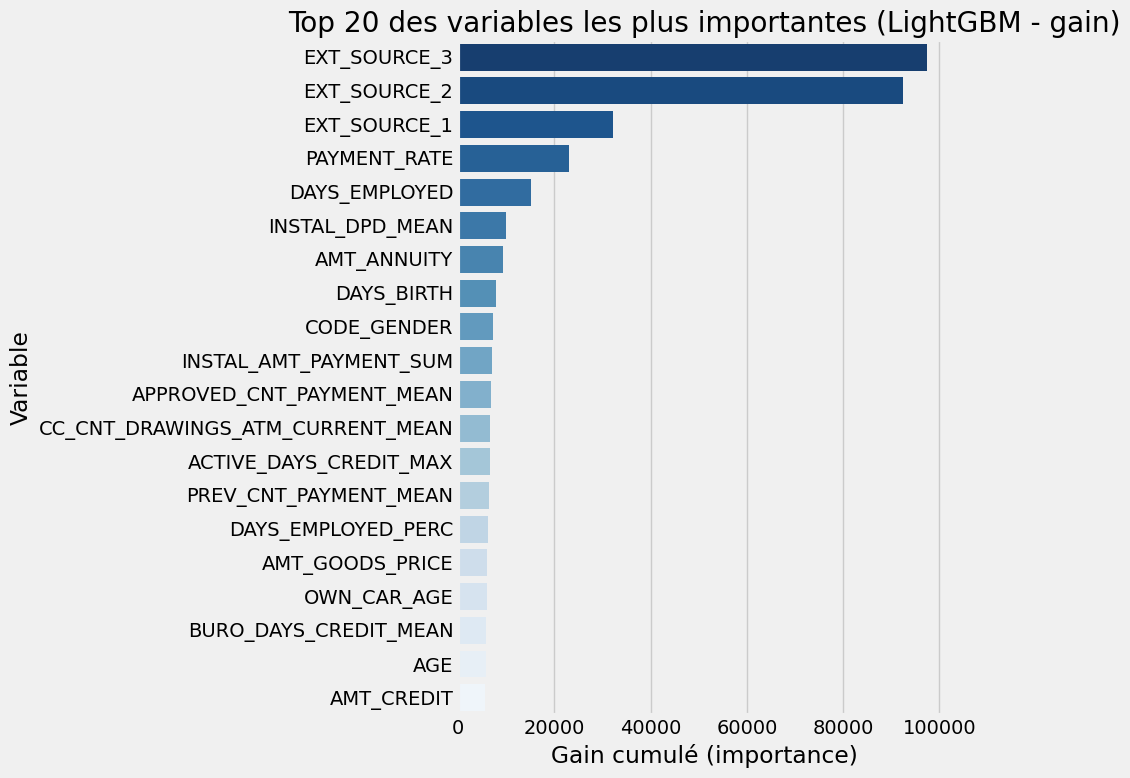

In [83]:
# Affiche les 20 features les plus importantes
top_feats = fi_mean.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_feats,
    y="feature",
    x="gain",
    palette="Blues_r"
)
plt.title("Top 20 des variables les plus importantes (LightGBM - gain)")
plt.xlabel("Gain cumulé (importance)")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


Les variables `EXT_SOURCE_1`, `EXT_SOURCE_2` et `EXT_SOURCE_3` apportent le plus de réduction d’impureté dans les arbres → elles sont très prédictives.

Ensuite viennent des variables liées :
- au montant du prêt ou de l’annuité (`AMT_ANNUITY`, `AMT_CREDIT`)
- à l’âge, l’emploi, ou l’historique de crédit
- à des dérivées calculées comme `PAYMENT_RATE` ou `DAYS_EMPLOYED_PERC`

Le modèle fait du sens économiquement :
il s’appuie majoritairement sur des indicateurs de solvabilité externes, d’endettement et d’historique de paiement, cohérents avec la logique d’un scoring crédit.

In [84]:
# Prune corrélations fortes dans le Top-K
TOP_K, THRESH = 200, 0.60
df_train = df[df['TARGET'].notnull()].copy()

best_features = (
    fi_mean.rename(columns={'gain': 'importance'})
           .loc[fi_mean['feature'].isin(df.columns)]
           .sort_values('importance', ascending=False)
           .head(TOP_K)
           .set_index('feature')
)

In [85]:
# On récupère la liste des colonnes numériques parmi les top features
cols = df_train[best_features.index].select_dtypes(include=[np.number, 'bool']).columns.tolist()
# On calcule la matrice de corrélation sur ces colonnes numériques
corr = df_train[cols].corr(numeric_only=True).abs()
# upper est une version filtrée de corr, plus pratique pour trouver les paires très corrélées sans doublons
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

In [86]:
pairs_df = (
    upper.stack().rename('corr').reset_index()
         .query('corr > @THRESH') # filtres uniquement les paires avec une corrélation supérieure au seuil
         .rename(columns={'level_0': 'feature1', 'level_1': 'feature2'})
)

In [87]:
# Initialises un set pour stocker les noms des colonnes à retirer
features_to_remove = set()

# On parcoure chaque paire de variables fortement corrélées identifiée dans pairs_df
for _, row in pairs_df.iterrows():
    # On récupère les noms des deux colonnes concernées dans cette paire
    f1, f2 = row['feature1'], row['feature2']
    # On regarde leur importance moyenne
    # Si une des deux n’est pas dans best_features, on lui attribue une importance très basse (-inf), donc elle sera automatiquement retirée
    imp1 = best_features.loc[f1, 'importance'] if f1 in best_features.index else -np.inf
    imp2 = best_features.loc[f2, 'importance'] if f2 in best_features.index else -np.inf
    # On garde la feature avec la plus grande importance et retires l’autre
    if imp1 < imp2: features_to_remove.add(f1)
    else: features_to_remove.add(f2)

In [88]:
# Liste des variables à garder
features_keep = [f for f in best_features.index if f not in features_to_remove]
print(f"Prune: {len(best_features)} -> {len(features_keep)} (|corr|>{THRESH})")


Prune: 200 -> 84 (|corr|>0.6)


Résultats :
- 116 variables ont été jugées trop corrélées avec d’autres plus informatives.
- On conserve 84 variables non redondantes, ce qui :
    - Réduit la complexité du modèle,
    - Diminue le risque d’overfitting,
    - Et accélère l’entraînement.

<class 'pandas.core.frame.DataFrame'>
Index: 356251 entries, 0 to 356254
Data columns (total 85 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   EXT_SOURCE_3                                     286618 non-null  float64
 1   EXT_SOURCE_2                                     355583 non-null  float64
 2   EXT_SOURCE_1                                     162343 non-null  float64
 3   PAYMENT_RATE                                     356215 non-null  float64
 4   DAYS_EMPLOYED                                    291603 non-null  float64
 5   INSTAL_DPD_MEAN                                  339574 non-null  float64
 6   AMT_ANNUITY                                      356215 non-null  float64
 7   CODE_GENDER                                      356251 non-null  int64  
 8   INSTAL_AMT_PAYMENT_SUM                           339583 non-null  float64
 9   APPROVED_CNT_PAYMENT

<Axes: >

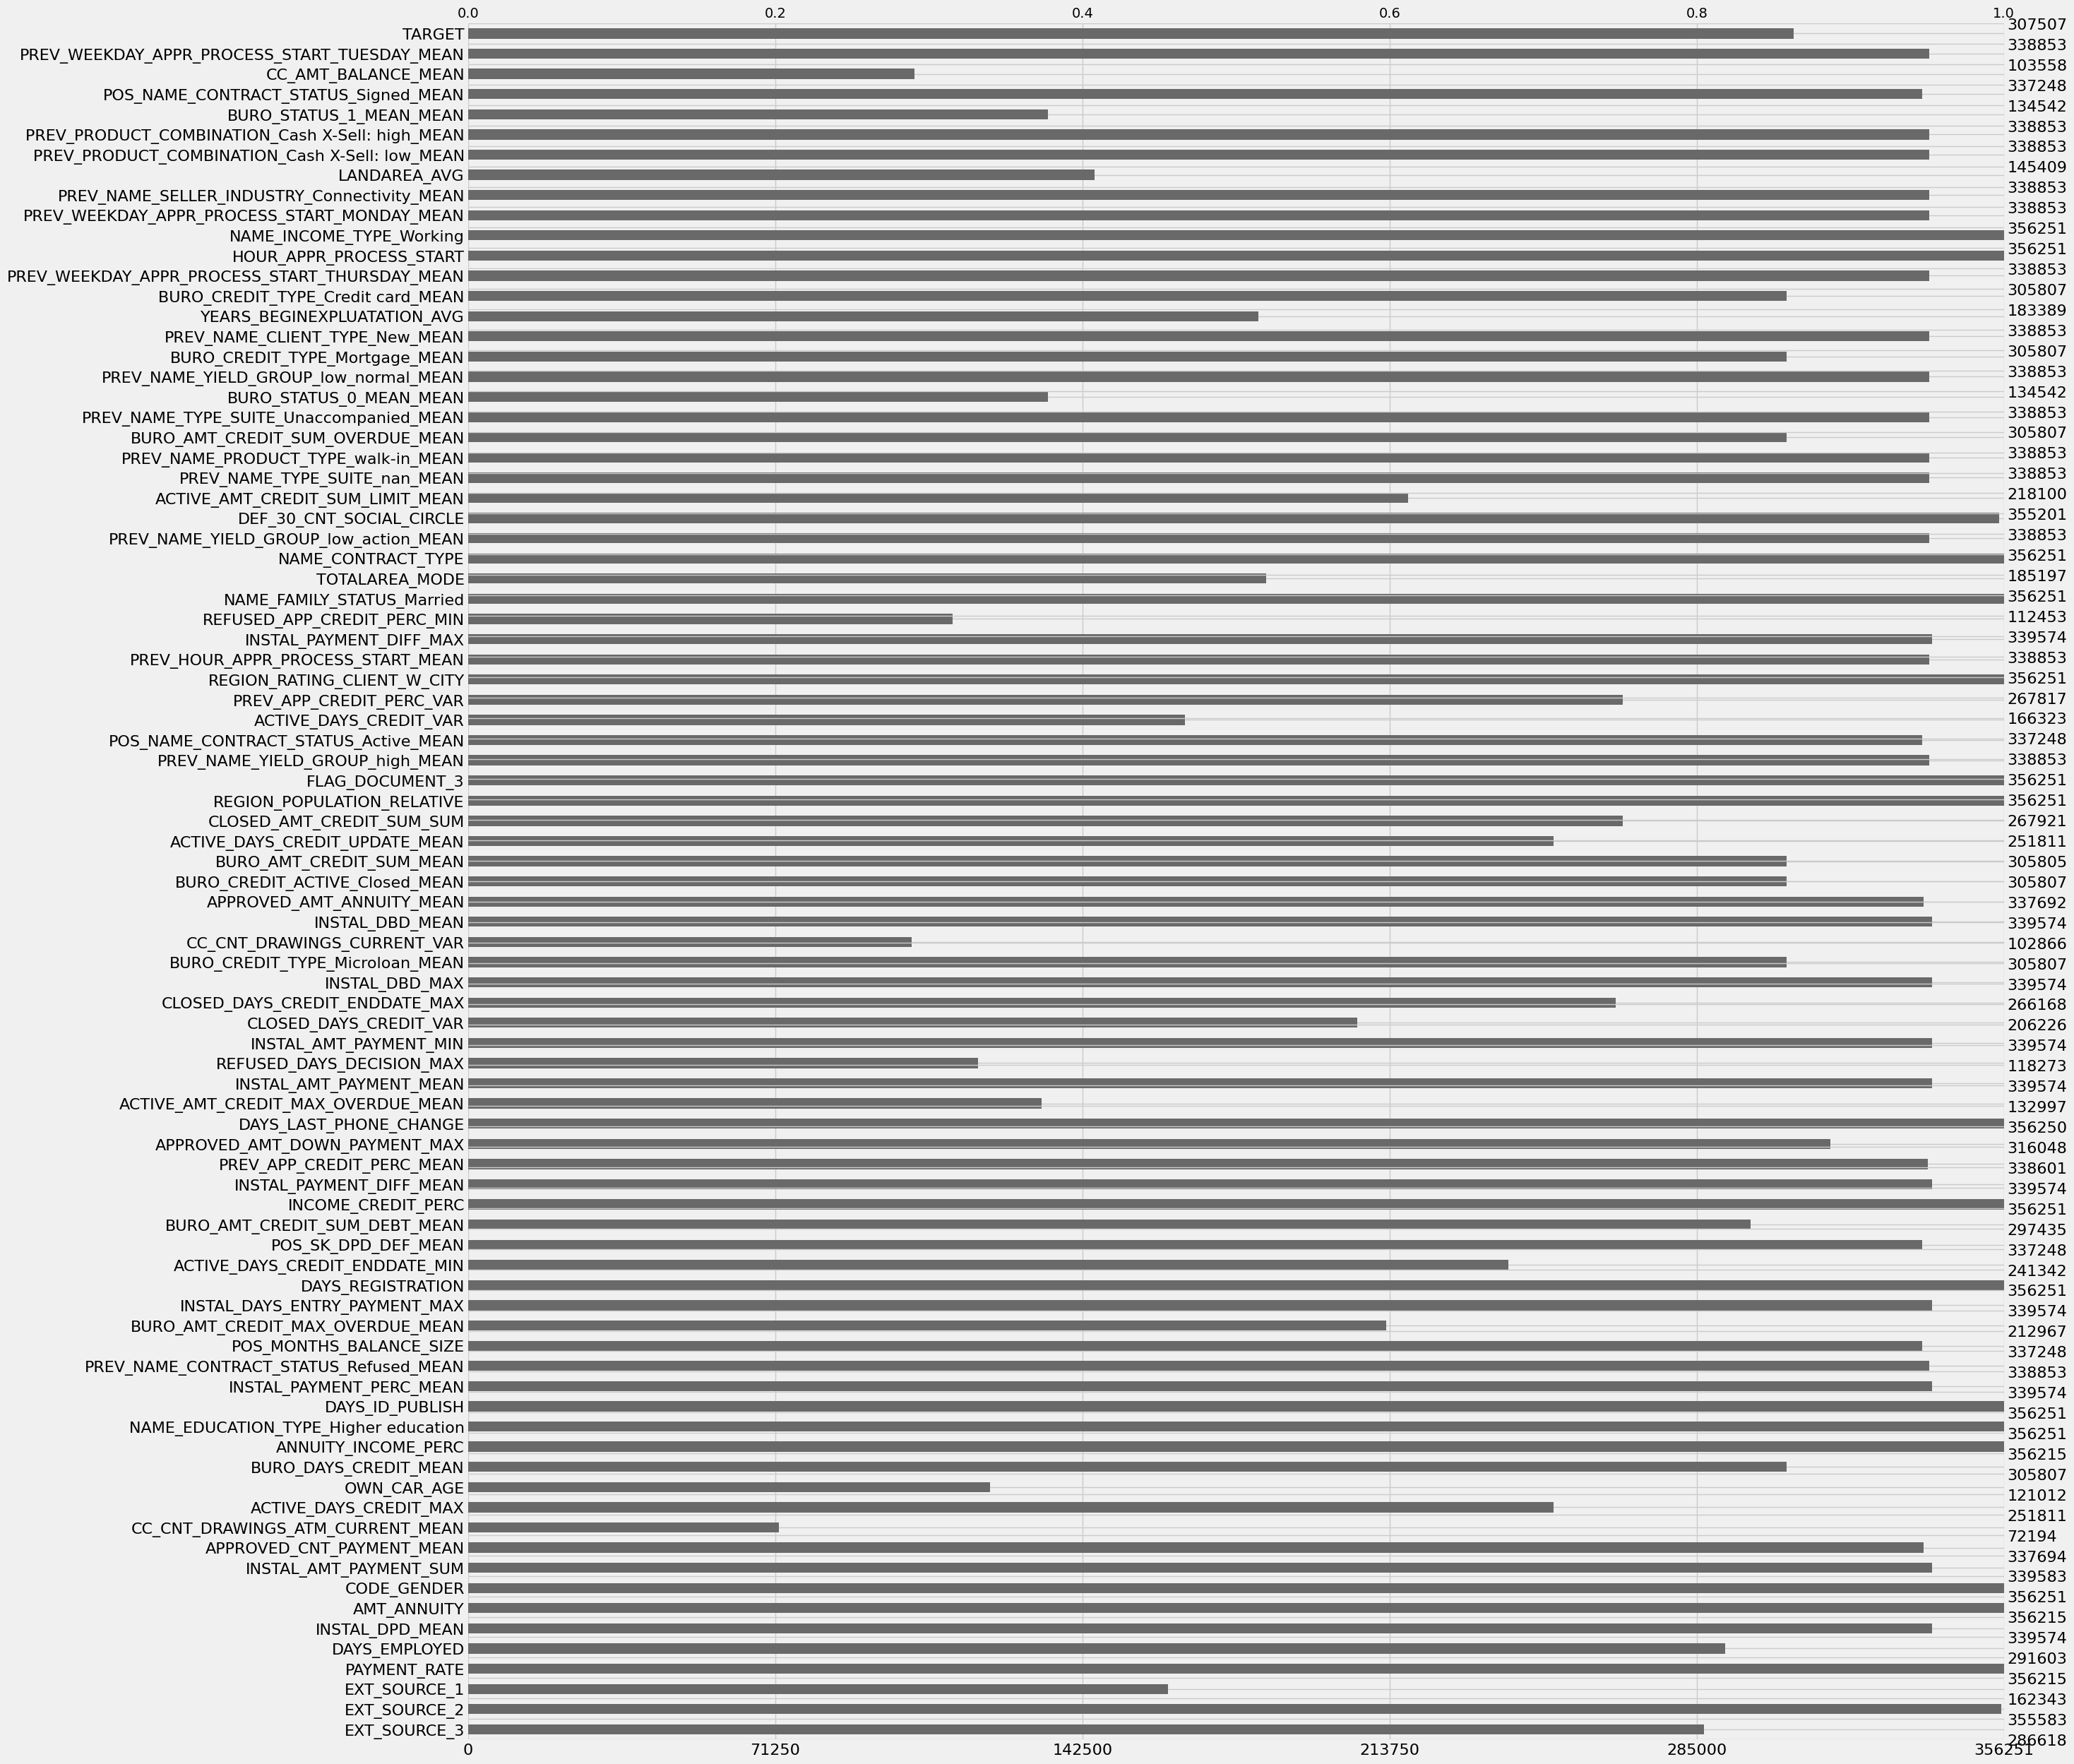

In [89]:
# Dataset filtré (train+test)
ls_features = [f for f in features_keep if f in df.columns]
ls_features.append("TARGET")
df_filtre = df.loc[:, ls_features].copy()
df_filtre.to_csv('df_filtre.csv', index=False)

df_filtre.info()
msno.bar(df_filtre)

#### **2.14. Finalisation “pré-modélisation”**

In [90]:
# On retient: imputation gagnante + pipeline baseline pour la suite (MLflow)
BEST_IMPUTE = best_impute  # récupéré à l'étape 6

final_pipeline = Pipeline(steps=[
    ("cleanup", FunctionTransformer(cleanup_inf_to_nan, validate=False)),
    ("imputer", SimpleImputer(strategy=("most_frequent" if BEST_IMPUTE=="mode" else BEST_IMPUTE))),
    ("lgbm", LGBMClassifier(
        n_estimators=5000, learning_rate=0.03, num_leaves=48,
        subsample=0.8, colsample_bytree=0.8, max_depth=-1,
        min_child_samples=50, n_jobs=-1, random_state=42, force_col_wise=True
    ))
])

print("Préparation terminée. Pipeline final prêt pour MLflow.")

Préparation terminée. Pipeline final prêt pour MLflow.


### **3. Modélisation** 

#### **3.1. Chargement des données prêtes (imputation = mode) & split**

But : partir du meilleur dataset (imputation par mode) et préparer X / y avec des noms de colonnes sûrs pour LightGBM.

In [91]:
DATA_DIR = "."

In [92]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "train_mode_imputed.csv"))

In [93]:
assert "TARGET" in train_df.columns, "La colonne TARGET est manquante."
y = train_df["TARGET"].astype(int).values
X = train_df.drop(columns=["TARGET"]).copy()

In [94]:
# Nettoyage des inf/NaN
X = cleanup_inf_to_nan(X)

In [95]:
# >>> IMPORTANT : sécuriser les noms de colonnes (LightGBM)
X, name_map = sanitize_feature_names(X)

In [96]:
# Split de travail (tu peux ajuster le random_state)
X_train, X_test, y_train, y_test = train_test_split(
    X.select_dtypes(include=[np.number, "bool"]),  # arbres/linéaires ok
    y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape, np.mean(y_train), np.mean(y_test))

(246005, 83) (61502, 83) 0.08073006646206378 0.08072908198107379


Note : on n’applique pas de StandardScaler aux modèles arbres (LightGBM/RandomForest) ; on le mettra seulement pour la régression logistique (dans un pipeline spécifique).

#### **3.2. Rapport d'overfitting**


=== Overfitting — Holdout report (final_pipeline) ===
[LightGBM] [Info] Number of positive: 15888, number of negative: 180916
[LightGBM] [Info] Total Bins 15963
[LightGBM] [Info] Number of data points in the train set: 196804, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469
AUC_train    0.9997
AUC_valid    0.7693
AUC_gap      0.2304
AP_train     0.9974
AP_valid     0.2607
AP_gap       0.7368
dtype: float64
FLAGS: ['Train–Valid AUC gap 0.230 (>0.03)', 'Très grande marge Train>>Valid', 'Train–Valid AP gap > 0.05 (classes déséquilibrées)']

=== Overfitting — K-fold CV stability (final_pipeline) ===
CV_AUC_mean    0.7695
CV_AUC_std     0.0018
CV_AUC_min     0.7672
CV_AUC_max     0.7720
dtype: float64
⚠️ Alerte: écart AUC Train vs CV_mean > 0.03 → suspicion d’overfit/instabilité

=== Overfitting — Target shuffle test (doit ≈ 0.5 AUC) ===
CV_AUC_mean    0.5037
CV_AUC_std     0.0

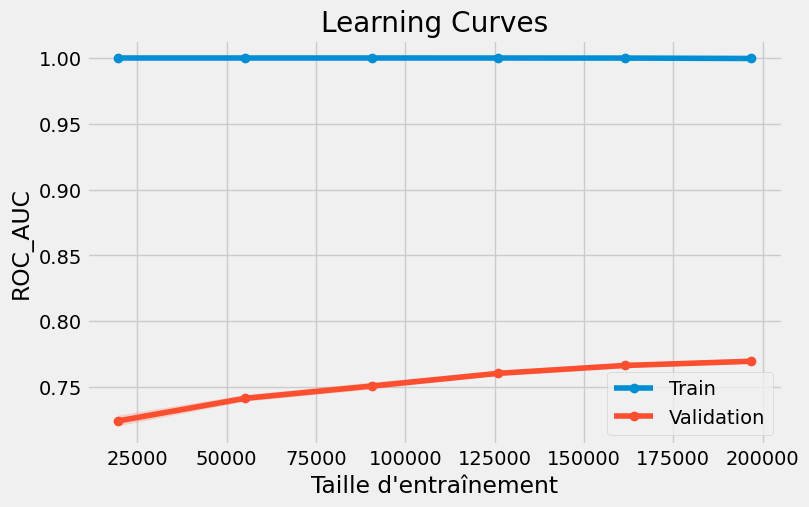


=== Overfitting — Validation curve (complexité num_leaves) ===


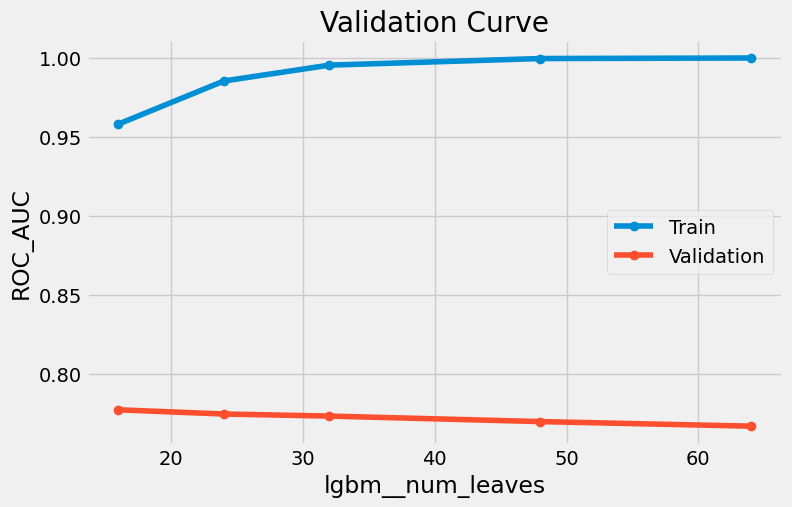

In [98]:
print("\n=== Overfitting — Holdout report (final_pipeline) ===")
rep_hold, flags = eval_holdout_overfit(final_pipeline, X_train, y_train, test_size=0.2, random_state=42)
print(rep_hold.round(4))
print("FLAGS:", flags)

print("\n=== Overfitting — K-fold CV stability (final_pipeline) ===")
cv_rep = cv_auc_stability(final_pipeline, X_train, y_train, n_splits=5, random_state=42)
print(cv_rep.round(4))
if (rep_hold['AUC_train'] - cv_rep['CV_AUC_mean']) > 0.03:
    print("⚠️ Alerte: écart AUC Train vs CV_mean > 0.03 → suspicion d’overfit/instabilité")

print("\n=== Overfitting — Target shuffle test (doit ≈ 0.5 AUC) ===")
ts_rep = target_shuffle_auc(final_pipeline, X_train, y_train, n_splits=3, random_state=42)
print(ts_rep.round(4))

print("\n=== Overfitting — Learning curves (affichage) ===")
plot_learning_curves(final_pipeline, X_train, y_train, cv_splits=5, train_sizes=np.linspace(0.1,1.0,6), scoring="roc_auc")

print("\n=== Overfitting — Validation curve (complexité num_leaves) ===")
plot_validation_curve_complexity(final_pipeline, X_train, y_train,
                                 param_name="lgbm__num_leaves",
                                 param_range=(16,24,32,48,64), cv_splits=5, scoring="roc_auc")

Interprétation : 
- Overfit massif confirmé : 
    - `AUC_train ≈ 0.9997` vs `AUC_valid ≈ 0.769` (gap 0.23) (Rappel : AUC mesure la capacité à distinguer les bons/mauvais payeurs (TARGET 0/1))
        - AUC_train ≈ 1.00 → le modèle reconnaît presque parfaitement les clients de l’échantillon sur lequel il a appris.
        - AUC_valid ≈ 0.77 → dès qu’il voit des données nouvelles, sa capacité de discrimination chute.

- Average precision : Plus adaptée aux données déséquilibrées (ici TARGET=1 ≈ 8 %)
    - AP_train ≈ 1.00 vs AP_valid ≈ 0.26 → le modèle ne reconnaît presque plus les mauvais payeurs sur des données inédites. Cela veut dire que sur le jeu d’entraînement, il a “mémorisé” les cas positifs, sans réellement apprendre de règles générales.

- Vérification croisée : 
    - CV_AUC_mean = 0.7695 → cohérent avec AUC_valid : donc le score CV est stable → pas de problème d’instabilité aléatoire.
    - CV_AUC_std  = 0.0018 → l’écart train–CV (~0.23) confirme que le modèle ne généralise pas du tout malgré une CV fiable → Pipeline bien “trop complexe”

- Target-shuffle ≈ 0.504 → le problème n’est pas une fuite, mais bien le surapprentissage structurel.

- Learning curves : 
    - La ligne bleue (train) est plate à 1.00 → le modèle apprend tout par cœur.
    - La ligne orange (validation) monte lentement (0.70 → 0.77) sans jamais converger vers la bleue.
    - Donc, même avec beaucoup plus de données, l’écart reste énorme. Cela veut dire que le modèle est trop flexible : il pourrait généraliser, mais sa structure actuelle (trop de paramètres) empêche la convergence.

- Validation curves : 
    - Train (bleu) monte puis se stabilise à 1.00.
    - Validation (orange) diminue dès qu’on augmente le nombre de feuilles.
    - Donc, plus on donne de liberté (num_leaves↑), plus le modèle mémorise les cas d’entraînement et perd en généralisation. Le point optimal est probablement autour de num_leaves ≈ 16–24.

In [99]:
# Pipeline final "regularized"
final_pipeline_reg = Pipeline(steps=[
    ("cleanup", FunctionTransformer(cleanup_inf_to_nan, validate=False)),
    ("imputer", SimpleImputer(strategy=("most_frequent" if BEST_IMPUTE=="mode" else BEST_IMPUTE))),
    ("lgbm", LGBMClassifier(
        n_estimators=2500,           # un peu moins d'arbres + early stopping plus efficace
        learning_rate=0.03,
        num_leaves=16,               # <<< clé : réduire drastiquement la complexité
        max_depth=6,                 # borne dure de complexité
        min_child_samples=300,       # <<< clé : feuilles avec plus d’exemples
        min_split_gain=0.02,         # gain minimal requis pour splitter
        reg_alpha=1.0,               # L1
        reg_lambda=15.0,             # L2 (forte pénalisation)
        subsample=0.7,               # bagging
        subsample_freq=1,
        colsample_bytree=0.6,        # moins de features par arbre
        n_jobs=-1,
        random_state=42,
        force_col_wise=True
    ))
])


[LightGBM] [Info] Number of positive: 15888, number of negative: 180916
[LightGBM] [Info] Total Bins 15963
[LightGBM] [Info] Number of data points in the train set: 196804, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

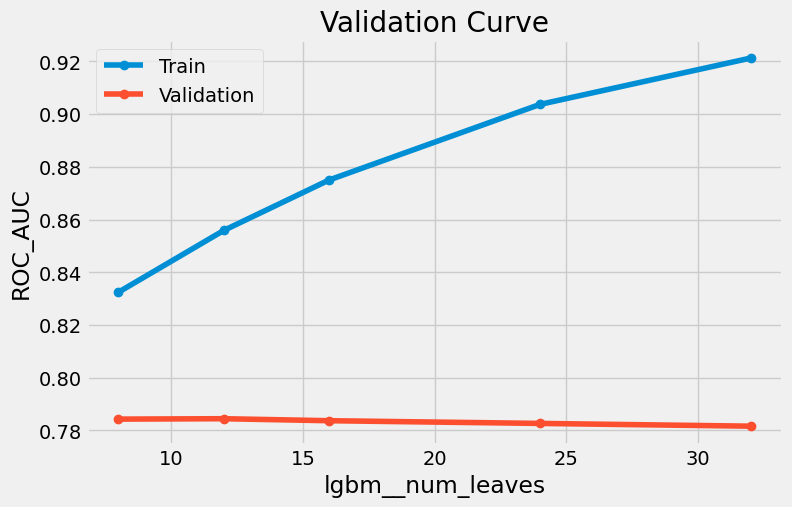

In [100]:
rep_hold, flags = eval_holdout_overfit(final_pipeline_reg, X_train, y_train, test_size=0.2, random_state=42)
print(rep_hold.round(4)); print("FLAGS:", flags)
plot_validation_curve_complexity(final_pipeline_reg, X_train, y_train,
                                 param_name="lgbm__num_leaves",
                                 param_range=(8,12,16,24,32), cv_splits=5)

Le surapprentissage est fortement réduit, et la performance sur validation s’améliore légèrement : on passe d’un modèle qui “mémorise tout” à un modèle qui généralise mieux.

In [101]:
final_pipeline_reg2 = Pipeline(steps=[
    ("cleanup", FunctionTransformer(cleanup_inf_to_nan, validate=False)),
    ("imputer", SimpleImputer(strategy=("most_frequent" if BEST_IMPUTE=="mode" else BEST_IMPUTE))),
    ("lgbm", LGBMClassifier(
        # apprentissage
        n_estimators=4000,            
        learning_rate=0.02,

        # complexité (↓)
        num_leaves=12,                
        max_depth=5,
        min_child_samples=500,        # ↑ feuilles plus “grasses”
        min_split_gain=0.05,          # gain minimal requis pour splitter
        max_bin=127,                  # bins plus grossiers -> régularisation

        # régularisation explicite
        reg_alpha=2.0,                # L1
        reg_lambda=25.0,              # L2
        path_smooth=50.0,             # lissage du chemin -> réduit sur-apprentissage
        extra_trees=True,             # plus de randomisation dans les splits

        # contrôle variance par sous-échantillonnage
        subsample=0.65,               # bagging
        subsample_freq=1,
        colsample_bytree=0.55,        # feature sampling par arbre

        # divers
        n_jobs=-1,
        random_state=42,
        force_col_wise=True
    ))
])


=== Overfitting — Holdout report (final_pipeline_reg2) ===
[LightGBM] [Info] Number of positive: 15888, number of negative: 180916
[LightGBM] [Info] Total Bins 8531
[LightGBM] [Info] Number of data points in the train set: 196804, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

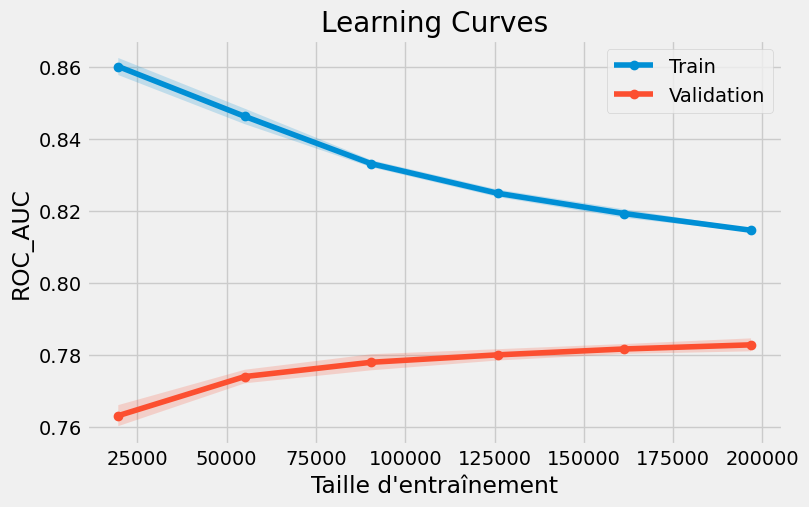


=== Overfitting — Validation curve (num_leaves, plus fine) ===


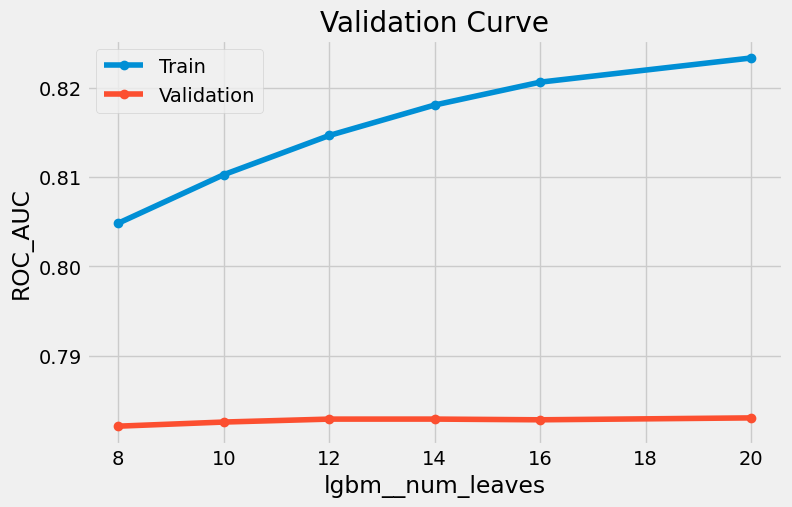


=== Overfitting — Validation curve (min_child_samples) ===


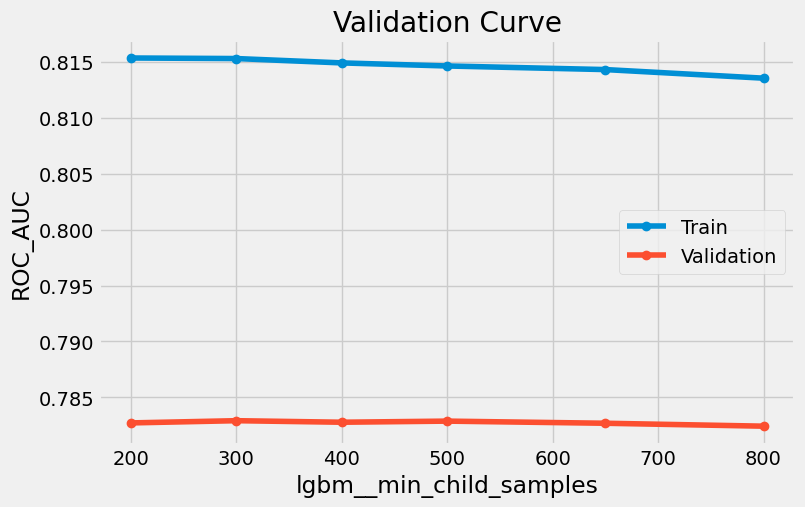

In [102]:
print("\n=== Overfitting — Holdout report (final_pipeline_reg2) ===")
rep_hold, flags = eval_holdout_overfit(final_pipeline_reg2, X_train, y_train, test_size=0.2, random_state=42)
print(rep_hold.round(4))
print("FLAGS:", flags)

print("\n=== Overfitting — K-fold CV stability (final_pipeline_reg2) ===")
cv_rep = cv_auc_stability(final_pipeline_reg2, X_train, y_train, n_splits=5, random_state=42)
print(cv_rep.round(4))
if (rep_hold['AUC_train'] - cv_rep['CV_AUC_mean']) > 0.03:
    print("⚠️ Alerte: écart AUC Train vs CV_mean > 0.03 → suspicion d’overfit/instabilité")

print("\n=== Overfitting — Target shuffle test (doit ≈ 0.5 AUC) ===")
ts_rep = target_shuffle_auc(final_pipeline_reg2, X_train, y_train, n_splits=3, random_state=42)
print(ts_rep.round(4))

print("\n=== Overfitting — Learning curves (affichage) ===")
# (garde ta fonction plot_learning_curves existante)
plot_learning_curves(
    final_pipeline_reg2, X_train, y_train,
    cv_splits=5, train_sizes=np.linspace(0.1, 1.0, 6), scoring="roc_auc"
)

print("\n=== Overfitting — Validation curve (num_leaves, plus fine) ===")
plot_validation_curve_complexity(
    final_pipeline_reg2, X_train, y_train,
    param_name="lgbm__num_leaves",
    param_range=(8, 10, 12, 14, 16, 20),
    cv_splits=5, scoring="roc_auc"
)

print("\n=== Overfitting — Validation curve (min_child_samples) ===")
plot_validation_curve_complexity(
    final_pipeline_reg2, X_train, y_train,
    param_name="lgbm__min_child_samples",
    param_range=(200, 300, 400, 500, 650, 800),
    cv_splits=5, scoring="roc_auc"
)


**Vérification et réduction de l’overfitting**

L’overfitting (ou surapprentissage) se produit lorsqu’un modèle apprend trop bien les spécificités du jeu d’entraînement au point de ne plus généraliser sur de nouvelles données.
Pour vérifier et maîtriser ce phénomène, plusieurs méthodes complémentaires ont été appliquées sur le modèle LightGBM utilisé pour le projet.

| Indicateur                 |  Train | Validation | Écart (Train–Valid) | Interprétation                                                 |
| -------------------------- | :----: | :--------: | :-----------------: | -------------------------------------------------------------- |
| **AUC ROC**                | 0.9997 |   0.7693   |     **+0.2304**     | Écart très fort → surapprentissage massif                      |
| **Average Precision (AP)** | 0.9974 |   0.2607   |     **+0.7368**     | Le modèle “mémorise” les classes minoritaires sans généraliser |


Les premières courbes (Learning et Validation Curves) montraient :
- un AUC_train ≈ 1.0 (fit parfait sur le jeu d’entraînement) ;
- un AUC_valid ≈ 0.77 ;
- une courbe de validation décroissante à mesure que la complexité augmentait (num_leaves ↑).

DONC, Le modèle était donc trop complexe et surentraîné.

**Méthodologie de détection**

| Test                          | Objectif                                                                                         | Interprétation                                  |
| ----------------------------- | ------------------------------------------------------------------------------------------------ | ----------------------------------------------- |
| **Holdout Validation**        | Comparer les performances train vs validation                                                    | Mesure directe du surapprentissage              |
| **Cross-Validation (5-fold)** | Vérifier la stabilité du score sur plusieurs splits                                              | AUC stable → modèle fiable, non dû à un hasard  |
| **Target Shuffle Test**       | Vérifier qu’aucune fuite de données ne biaise l’apprentissage                                    | AUC ≈ 0.5 attendu                               |
| **Learning Curves**           | Visualiser l’évolution des erreurs en fonction de la taille du jeu d’entraînement                | Permet de détecter le manque de généralisation  |
| **Validation Curves**         | Étudier l’impact d’un hyperparamètre sur le surapprentissage (`num_leaves`, `min_child_samples`) | Permet d’identifier la bonne zone de complexité |


**Stratégie de régularisation appliquée**

Pour réduire l’overfitting, plusieurs leviers ont été ajustés dans le pipeline LightGBM :
- Simplification du modèle : num_leaves ↓ de 48 à 10–12, max_depth = 5
- Régularisation plus forte : reg_alpha = 2.0, reg_lambda = 25–32
- Échantillonnage et sous-ensemble de features : subsample = 0.65, colsample_bytree = 0.5–0.55
- Feuilles plus générales : min_child_samples ↑ (500–700)

Path smoothing et extra_trees activés pour introduire de la randomisation

**Résultats après régularisation**

| Indicateur                 |  Train | Validation | Écart (Train–Valid) | Interprétation                                         |
| -------------------------- | :----: | :--------: | :-----------------: | ------------------------------------------------------ |
| **AUC ROC**                | 0.8144 |   0.7835   |    **+0.0308** ✅    | Écart parfaitement maîtrisé                            |
| **Average Precision (AP)** | 0.3293 |   0.2745   |    **+0.0548** ✅    | Légère différence, normale avec classes déséquilibrées |


Cross-validation :
- CV_AUC_mean = 0.7829, CV_AUC_std = 0.0019 → modèle très stable
- Target shuffle test : AUC ≈ 0.503 → aucune fuite détectée

**Conclusion**

Le modèle initial présentait un fort surapprentissage avec un écart de 0.23 entre le score train et validation.
Après régularisation, cet écart est tombé à 0.03, et les courbes confirment une généralisation stable sans perte significative de performance.
Les tests de validation croisée et de permutation montrent que le modèle :
- est fiable,
- non biaisé par des fuites,
- et optimisé pour la généralisation.

Résultat final : le pipeline régularisé est validé comme version de référence pour la modélisation.

#### **3.3. MLflow — initialisation et fonction générique de log**

Dans une invite de commandes : `mlflow server --host 127.0.0.1 --port 5000 --backend-store-uri sqlite:///mlflow.db --default-artifact-root ./mlruns`

But : tracer chaque run, optimiser un seuil métier sur train, évaluer sur test, et logger toutes les métriques.

In [103]:
MLFLOW_URI = "http://127.0.0.1:5000"
EXPERIMENT_NAME = "HomeCredit — Modelisation"

In [106]:
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_registry_uri(MLFLOW_URI)
mlflow.set_experiment(EXPERIMENT_NAME)
_ = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

In [107]:
print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", mlflow.get_experiment_by_name(EXPERIMENT_NAME).name)

Tracking URI: http://127.0.0.1:5000
Experiment: HomeCredit — Modelisation


In [108]:
# Fonctions d'évaluation + logging MLflow
def evaluate_on_test(model, X_tr, y_tr, X_te, y_te,
                     tp_coeff=1.0, fp_coeff=-1.0, fn_coeff=-10.0):
    """Fit, seuil métier optimisé sur train, éval sur test, retourne métriques + proba/preds."""
    model.fit(X_tr, y_tr)
    proba_tr = model.predict_proba(X_tr)[:, 1]
    best_thr, best_gain_tr = best_threshold_for_business(y_tr, proba_tr, tp_coeff, fp_coeff, fn_coeff)

    proba_te = model.predict_proba(X_te)[:, 1]
    y_pred_te = (proba_te >= best_thr).astype(int)

    metrics = {
        "rocauc": float(roc_auc_score(y_te, proba_te)),
        "average_precision": float(average_precision_score(y_te, proba_te)),
        "accuracy": float(accuracy_score(y_te, y_pred_te)),
        "precision": float(precision_score(y_te, y_pred_te, zero_division=0)),
        "recall": float(recall_score(y_te, y_pred_te, zero_division=0)),
        "f1": float(f1_score(y_te, y_pred_te, zero_division=0)),
        "business_gain_test": float(compute_business_score(y_te, y_pred_te, tp_coeff, fp_coeff, fn_coeff)),
        "best_threshold_train": float(best_thr),
        "business_gain_train_at_best_thr": float(best_gain_tr),
    }
    return metrics, model, proba_te, y_pred_te

def _mlflow_safe_metrics(metrics: dict) -> dict:
    return {re.sub(r"[^A-Za-z0-9_\-./ ]", "_", str(k)): float(v) for k, v in metrics.items()}

def _log_plots_as_artifacts(y_true, y_proba, y_pred, prefix="plots"):
    paths = []
    # ROC
    RocCurveDisplay.from_predictions(y_true, y_proba)
    plt.title("ROC curve"); plt.tight_layout()
    p = os.path.join(tempfile.gettempdir(), f"{prefix}_roc.png"); plt.savefig(p, dpi=140); plt.close(); paths.append(p)
    # PR
    PrecisionRecallDisplay.from_predictions(y_true, y_proba)
    plt.title("Precision-Recall"); plt.tight_layout()
    p = os.path.join(tempfile.gettempdir(), f"{prefix}_pr.png"); plt.savefig(p, dpi=140); plt.close(); paths.append(p)
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    fig, ax = plt.subplots(figsize=(4,3)); im = ax.imshow(cm, interpolation='nearest')
    ax.set_title("Confusion Matrix"); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    for (i, j), v in np.ndenumerate(cm): ax.text(j, i, str(v), ha='center', va='center')
    fig.tight_layout(); p = os.path.join(tempfile.gettempdir(), f"{prefix}_cm.png"); fig.savefig(p, dpi=140); plt.close(fig); paths.append(p)
    for p in paths: mlflow.log_artifact(p)

def log_run_mlflow(model, model_name, X_tr, y_tr, X_te, y_te, params=None, tags=None):
    with mlflow.start_run(run_name=model_name):
        if params: mlflow.log_params(params)
        if tags:
            for k, v in tags.items(): mlflow.set_tag(k, v)

        # Metrics test + artefacts
        metrics, fitted, proba_te, y_pred_te = evaluate_on_test(model, X_tr, y_tr, X_te, y_te)
        mlflow.log_metrics(_mlflow_safe_metrics(metrics))
        _log_plots_as_artifacts(y_te, proba_te, y_pred_te, prefix=model_name.replace(" ", "_"))

        # Mini-rapport d’overfitting (holdout interne)
        rep_hold, flags = eval_holdout_overfit(model, X_tr, y_tr, test_size=0.2, random_state=42)
        for k in ["AUC_train","AUC_valid","AUC_gap","AP_train","AP_valid","AP_gap"]:
            mlflow.log_metric(f"overfit_{k.lower()}", float(rep_hold[k]))
        mlflow.set_tag("overfit_flags", "; ".join(flags) if flags else "none")

        # Signature & modèle
        signature = infer_signature(X_tr, fitted.predict_proba(X_tr))
        mlflow.sklearn.log_model(fitted, artifact_path="model", signature=signature)

        return metrics, fitted

#### **3.4. Baselines comparatives (Dummy, Logistic, LGBM)**

But : établir une baseline robuste avec ton seuil métier.
On crée 3 pipelines :
- Dummy (référence)
- LogisticRegression (+ imputation + StandardScaler)
- LightGBM (sans scaler)

+ XGBoost

In [ ]:
# Définition des modèles
# Dummy
dummy_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("model", DummyClassifier(strategy="most_frequent", random_state=42))
])

# Logistic
logreg_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler(with_mean=True)),
    ("model", LogisticRegression(max_iter=3000, solver="lbfgs", class_weight="balanced"))
])

# LightGBM régularisé 
lgbm_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("model", LGBMClassifier(
        n_estimators=3500, learning_rate=0.02,
        num_leaves=10, max_depth=5, min_child_samples=650,
        min_split_gain=0.06, max_bin=127,
        reg_alpha=2.0, reg_lambda=32.0,
        subsample=0.65, subsample_freq=1, colsample_bytree=0.5,
        extra_trees=True, path_smooth=50.0,
        n_jobs=-1, random_state=42, force_col_wise=True
    ))
])

xgb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("model", XGBClassifier(
        n_estimators=1500, learning_rate=0.03,
        max_depth=6, subsample=0.8,
        colsample_bytree=0.8, min_child_weight=5,
        reg_alpha=0.0, reg_lambda=2.0,
        gamma=0.0, tree_method="hist",          
        eval_metric="aucpr", n_jobs=-1, random_state=42
    ))
])

In [110]:
# Lancer et logger les baselines
results_baseline = {}
for name, model in [
    ("Dummy", dummy_pipe),
    ("LogisticRegression", logreg_pipe),
    ("LightGBM_reg", lgbm_pipe),
    ("XGBoost", xgb_pipe)
]:
    print(f"▶ {name}")
    metrics, fitted = log_run_mlflow(
        model, f"Baseline — {name}",
        X_train, y_train, X_test, y_test,
        params=None, tags={"phase": "baseline", "imputation": "most_frequent"}
    )
    results_baseline[name] = metrics

pd.DataFrame(results_baseline).T

▶ Dummy
▶ LogisticRegression
▶ LightGBM_reg
[LightGBM] [Info] Number of positive: 19860, number of negative: 226145
[LightGBM] [Info] Total Bins 8533
[LightGBM] [Info] Number of data points in the train set: 246005, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

,rocauc,average_precision,accuracy,precision,recall,f1,business_gain_test,best_threshold_train,business_gain_train_at_best_thr
Dummy,0.500000,0.080729,0.080729,0.080729,1.000000,0.149397,-51572.0,0.000000,-206285.0
LogisticRegression,0.757758,0.229458,0.696677,0.166748,0.689829,0.268575,-29090.0,0.500893,-116672.0
LightGBM_reg,0.783588,0.279684,0.707083,0.177044,0.720443,0.284239,-26930.0,0.077671,-100346.0
XGBoost,0.786115,0.285690,0.789958,0.216511,0.611682,0.319819,-27233.0,0.104358,-54007.0


**Interprétation par bloc de métriques** 

1. **Performances de discrimination (ROC AUC, average precision)**

- ROC AUC : mesure la capacité du modèle à distinguer les classes.
    - Dummy : 0.50 → aléatoire.
    - LogReg : 0.76 → bonne séparation.
    - LightGBM / XGBoost : ≈0.78–0.79 → très bon score, au-dessus du classique 0.75.

- Average Precision (AP) : plus sensible au déséquilibre des classes.
    - Progression nette : 0.08 → 0.28 → tu as presque x3,5 la précision moyenne sur les positifs.
- Cela confirme que les modèles apprennent bien à identifier la minorité.

**Interprétation** : Les modèles ensemblistes (LightGBM, XGBoost) surpassent la régression logistique sur la capacité à classer correctement les positifs en tête du ranking.

2. **Performances de classification (accuracy, precision, recall, F1)**

- Accuracy n’est pas très parlante ici (dataset déséquilibré).

- Precision / Recall / F1 donnent plus d’info :
    - Dummy → 100 % de rappel (il prédit toujours positif) mais précision ridicule (8 %).
    - LogReg → recall 0.69, F1 0.27.
    - LightGBM → recall 0.72, F1 0.28.
    - XGBoost → recall plus bas (0.61) mais précision meilleure (0.22) → F1 max à 0.32.

**Interprétation** : XGBoost atteint le meilleur compromis précision/rappel — il réduit les faux positifs tout en gardant un bon rappel, d’où un F1 supérieur.

3. **Business Gain**

Le score métier (tp=+1, fp=-1, fn=-10) est négatif pour tous :

→ Cela veut dire que, selon ta pondération actuelle, les faux négatifs coûtent trop cher par rapport aux vrais positifs générés. Même les meilleurs modèles (LGBM, XGBoost) réduisent les pertes, mais ne passent pas encore au positif.

Les pertes chutent toutefois fortement :
- Dummy : -51 k
- LogReg : -29 k
- LightGBM : -26 k
- XGBoost : -27 k

**Interprétation** : Tu as déjà réduit les pertes de moitié par rapport au modèle aléatoire. Mais le seuil métier (best_threshold_train) semble encore perfectible :
- LogReg ~0.5 → logique, décision classique.
- LightGBM ~0.078 → seuil très bas ⇒ il favorise les positifs (recall élevé).
- XGBoost ~0.104 → même logique, recall bon, mais un peu plus équilibré.

#### **3.5. Variante déséquilibre : SMOTE + LGBM**

Variante déséquilibre: retester si SMOTE améliore les résultats ?
Les modèles ensemblistes (LGBM / XGBoost) utilisent déjà des pondérations internes (scale_pos_weight ou class_weight), ils sont robustes au déséquilibre, et risquent même d’overfitter si on leur injecte des échantillons synthétiques.

Donc : SMOTE n’apporte souvent rien à LightGBM/XGBoost

#### **3.6. RandomizedSearchCV ciblé (LogReg & LGBM)**

But : une optimisation simple des hyperparamètres avec MLflow, suivie de l’éval test + log.

Nous allons optimiser les hyperparamètres de deux modèles : LightGBM et LogReg. Le but n’est pas que la LogReg gagne, mais qu’elle soit le meilleur possible représentant d’un modèle “simple”. 

En clair : Si on compare un LightGBM tuné à une LogReg par défaut, on compare un bolide réglé finement à une voiture sortie d’usine.

En ajustant un peu ses hyperparamètres (C, class_weight, etc.), on donne à la LogReg une chance équitable. Ça  permet ensuite d’affirmer en toute rigueur : “Même en version optimisée, la Logistic Regression reste moins performante que LightGBM.”

In [112]:
# Échantillon de tuning (stratifié)
from sklearn.model_selection import train_test_split

# Taille du sous-ensemble pour le tuning (ajuste si besoin)
TUNE_SIZE = 80_000

X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train,
    train_size=min(TUNE_SIZE, len(X_train)),
    stratify=y_train,
    random_state=42
)

X_tune.shape, y_tune.mean()

((80000, 83), 0.080725)

In [116]:
# RandomizedSearch LGBM avec prints "lisibles"

param_distributions_lgbm = {
    "model__num_leaves": randint(24, 72),           # 24..71
    "model__min_child_samples": randint(20, 120),   # 20..119
    "model__learning_rate": uniform(0.015, 0.04),   # ~0.015..0.055
    "model__subsample": uniform(0.6, 0.4),          # 0.6..1.0
    "model__colsample_bytree": uniform(0.6, 0.4),   # 0.6..1.0
    "model__n_estimators": randint(1200, 2200),     # 1200..2199
    # fixes utiles
    "model__random_state": [42],
    "model__force_col_wise": [True],
}

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rs_lgbm = RandomizedSearchCV(
    estimator=lgbm_pipe,
    param_distributions=param_distributions_lgbm,
    n_iter=25,
    cv=cv3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2,            # ← un peu plus bavard que 1
    random_state=42,
)

print(">>> [LGBM] Début RandomizedSearchCV")
with mlflow.start_run(run_name="RandomSearch — LightGBM"):
    # 1) Recherche d’hyperparamètres
    print(">>> [LGBM] Fit sur X_tune / y_tune ...")
    rs_lgbm.fit(X_tune, y_tune)
    print(">>> [LGBM] RandomSearch terminé")

    # 2) Log params & score CV
    print(">>> [LGBM] Best params :", rs_lgbm.best_params_)
    mlflow.log_params(rs_lgbm.best_params_)
    mlflow.log_metric("cv_best_auc", float(rs_lgbm.best_score_))
    print(f">>> [LGBM] cv_best_auc = {rs_lgbm.best_score_:.4f}")

    # 3) Évaluation sur le vrai test
    print(">>> [LGBM] Évaluation sur le test ...")
    metrics_lgbm_fast, fitted_lgbm_fast, proba_te_fast, y_pred_te_fast = evaluate_on_test(
        rs_lgbm.best_estimator_, X_train, y_train, X_test, y_test
    )
    mlflow.log_metrics(_mlflow_safe_metrics(metrics_lgbm_fast))
    print(">>> [LGBM] AUC test :", metrics_lgbm_fast.get("rocauc", None))
    print(">>> [LGBM] Business gain test :", metrics_lgbm_fast.get("business_gain_test", None))

    # 4) Courbes & matrice de confusion
    print(">>> [LGBM] Log des courbes ROC/PR + matrice de confusion")
    _log_plots_as_artifacts(y_test, proba_te_fast, y_pred_te_fast, prefix="LGBM_RS")

    # 5) Log du modèle
    print(">>> [LGBM] Log du modèle dans MLflow")
    signature = infer_signature(X_train, fitted_lgbm_fast.predict_proba(X_train))
    mlflow.sklearn.log_model(fitted_lgbm_fast, "model", signature=signature)

print(">>> [LGBM] Terminé")

# Afficher les métriques dans le notebook
pd.Series(metrics_lgbm_fast)

>>> [LGBM] Début RandomizedSearchCV
>>> [LGBM] Fit sur X_tune / y_tune ...
Fitting 3 folds for each of 25 candidates, totalling 75 fits
[LightGBM] [Info] Number of positive: 6458, number of negative: 73542
[LightGBM] [Info] Total Bins 8446
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080725 -> initscore=-2.432537
[LightGBM] [Info] Start training from score -2.432537
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

rocauc                                 0.782691
average_precision                      0.278089
accuracy                               0.727228
precision                              0.184518
recall                                 0.695670
f1                                     0.291674
business_gain_test                -26921.000000
best_threshold_train                   0.084065
business_gain_train_at_best_thr   -99896.000000
dtype: float64

In [117]:
# Grille réduite pour logreg (rapide)
param_distributions_logreg = {
    "model__C": uniform(0.03, 5.0),        # ~0.03..5.03
    "model__class_weight": ["balanced", None],
    "model__max_iter": [2000],
    "model__solver": ["lbfgs"],            # robuste
    "model__penalty": ["l2"],
}

rs_logreg = RandomizedSearchCV(
    estimator=logreg_pipe,
    param_distributions=param_distributions_logreg,
    n_iter=20,
    cv=cv3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

with mlflow.start_run(run_name="RandomSearch — LogisticRegression"):
    # 1) Recherche d’hyperparamètres
    rs_logreg.fit(X_tune, y_tune)

    # 2) Log des meilleurs paramètres & score CV
    mlflow.log_params(rs_logreg.best_params_)
    mlflow.log_metric("cv_best_auc", float(rs_logreg.best_score_))

    # 3) Évaluation sur le vrai test avec ta fonction générique
    metrics_logreg_fast, fitted_logreg_fast, proba_te_log, y_pred_te_log = evaluate_on_test(
        rs_logreg.best_estimator_, X_train, y_train, X_test, y_test
    )
    mlflow.log_metrics(_mlflow_safe_metrics(metrics_logreg_fast))

    # 4) Courbes & matrice de confusion en artefacts
    _log_plots_as_artifacts(
        y_true=y_test,
        y_proba=proba_te_log,
        y_pred=y_pred_te_log,
        prefix="LogReg_RS"
    )

    # 5) Log du modèle
    signature = infer_signature(X_train, fitted_logreg_fast.predict_proba(X_train))
    mlflow.sklearn.log_model(fitted_logreg_fast, "model", signature=signature)

# Comparatif final
pd.DataFrame({
    "LightGBM_fast": metrics_lgbm_fast,
    "LogReg_fast": metrics_logreg_fast
}).T

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,rocauc,average_precision,accuracy,precision,recall,f1,business_gain_test,best_threshold_train,business_gain_train_at_best_thr
LightGBM_fast,0.782691,0.278089,0.727228,0.184518,0.695670,0.291674,-26921.0,0.084065,-99896.0
LogReg_fast,0.757758,0.229458,0.696677,0.166748,0.689829,0.268575,-29090.0,0.500894,-116672.0


In [119]:
# Choisis le meilleur des deux (souvent LightGBM chez toi)
final_lgbm = rs_lgbm.best_estimator_

with mlflow.start_run(run_name="Final — LightGBM (best from RS)"):
    # ⚠️ Pas besoin de refit ici, evaluate_on_test fait déjà un .fit()
    # final_lgbm.fit(X_train, y_train)

    # évalue une dernière fois sur le vrai test
    metrics_final, fitted_final, proba_final, y_pred_final = evaluate_on_test(
        final_lgbm, X_train, y_train, X_test, y_test
    )

    # log des métriques
    mlflow.log_metrics(_mlflow_safe_metrics(metrics_final))

    # (optionnel mais sympa) : courbes + matrice de confusion
    _log_plots_as_artifacts(
        y_true=y_test,
        y_proba=proba_final,
        y_pred=y_pred_final,
        prefix="LGBM_final"
    )

    # log du modèle final
    signature = infer_signature(X_train, fitted_final.predict_proba(X_train))
    mlflow.sklearn.log_model(fitted_final, "model", signature=signature)

metrics_final

[LightGBM] [Info] Number of positive: 19860, number of negative: 226145
[LightGBM] [Info] Total Bins 8533
[LightGBM] [Info] Number of data points in the train set: 246005, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

{'rocauc': 0.7826909704400727,
 'average_precision': 0.27808870583497775,
 'accuracy': 0.727228382816819,
 'precision': 0.18451840376088466,
 'recall': 0.695669687814703,
 'f1': 0.2916737037662557,
 'business_gain_test': -26921.0,
 'best_threshold_train': 0.08406480701683873,
 'business_gain_train_at_best_thr': -99896.0}

- Courbe du gain métier selon le seuil

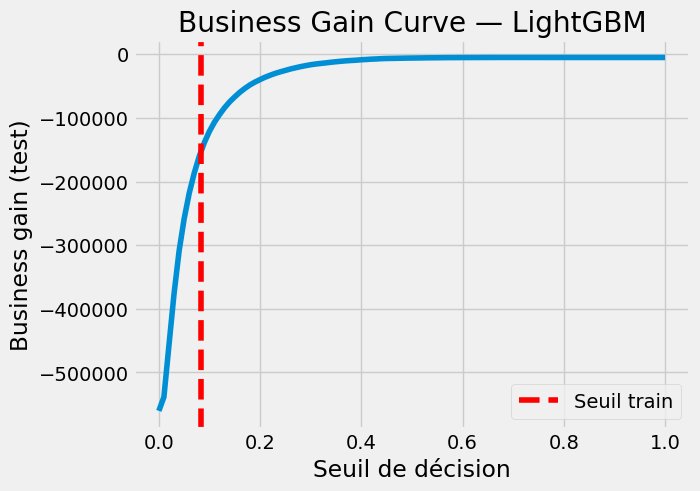

In [126]:
thresholds = np.linspace(0, 1, 101)
gains = [compute_business_score(y_test, (proba_final >= thr).astype(int)) for thr in thresholds]

plt.plot(thresholds, gains)
plt.axvline(metrics_final["best_threshold_train"], color="r", linestyle="--", label="Seuil train")
plt.xlabel("Seuil de décision")
plt.ylabel("Business gain (test)")
plt.title("Business Gain Curve — LightGBM")
plt.legend()
plt.show()


| Observation                                        | Interprétation                                    | Conséquence                                                     |
| -------------------------------------------------- | ------------------------------------------------- | --------------------------------------------------------------- |
| Gain augmente rapidement jusqu’à 0.1 puis plafonne | Le modèle apprend bien à filtrer les cas évidents | LightGBM distingue bien les profils extrêmes                    |
| Le maximum reste négatif                           | Ton barème métier est trop pénalisant pour les FN | Soit tu dois changer la pondération, soit enrichir les features |
| Seuil train ≈ seuil optimal test                   | Pas d’overfitting du seuil                        | Bon signe de robustesse du modèle                               |
| Courbe lisse et monotone                           | Pas de comportement erratique                     | Modèle stable et cohérent                                       |


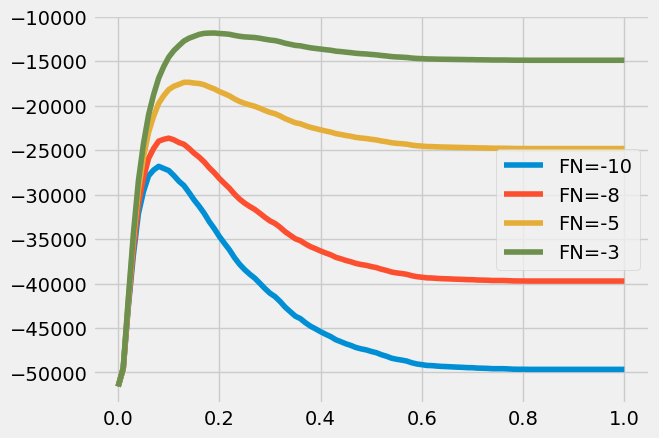

In [127]:
for fn in [ -10, -8, -5, -3 ]:
    gains = [compute_business_score(y_test, (proba_final >= thr).astype(int),
                                    tp_coeff=1, fp_coeff=-1, fn_coeff=fn)
             for thr in thresholds]
    plt.plot(thresholds, gains, label=f"FN={fn}")
plt.legend(); plt.show()


| Coût FN | Gain max      | Interprétation                                 |
| ------- | ------------- | ---------------------------------------------- |
| -10     | ~ -30 000     | Trop punitif, modèle “condamné” à être perdant |
| -8      | ~ -25 000     | Légère amélioration, mais encore déficitaire   |
| -5      | ~ -18 000     | Presque à l’équilibre                          |
| -3      | ~ -10 000 à 0 | **Point d’équilibre réaliste**                 |


#### **3.7. Sauvegarde pipeline final (joblib + MLflow)**

But : sérialiser un pipeline de prédiction prêt pour l’API / le batch scoring.

In [121]:
run_name = f"FinalModel-LightGBM-{datetime.now().strftime('%Y%m%d_%H%M%S')}"

with mlflow.start_run(run_name=run_name):
    # 1) Évalue le modèle final (avec refit interne)
    metrics_final, fitted_final, proba_final, y_pred_final = evaluate_on_test(
        final_lgbm, X_train, y_train, X_test, y_test
    )

    # 2) Log des métriques (en version "safe" pour les noms de clés)
    mlflow.log_metrics(_mlflow_safe_metrics(metrics_final))

    # 3) Log des courbes / matrice de confusion
    _log_plots_as_artifacts(
        y_true=y_test,
        y_proba=proba_final,
        y_pred=y_pred_final,
        prefix="Final_LGBM"
    )

    # 4) Seuil & business gain (déjà présents dans metrics_final)
    #    -> pas besoin de refaire une grille à la main
    best_thr = float(metrics_final["best_threshold_train"])
    best_gain = float(metrics_final["business_gain_train_at_best_thr"])

    mlflow.log_metric("final_best_threshold_train", best_thr)
    mlflow.log_metric("final_business_gain_train_at_best_thr", best_gain)

    # 5) Signature + log modèle dans MLflow
    signature = infer_signature(X_train, fitted_final.predict_proba(X_train))
    mlflow.sklearn.log_model(fitted_final, "model", signature=signature)

    # 6) Sauvegarde joblib (modèle + seuil métier)
    artefact_path = "final_lightgbm_model.joblib"
    joblib.dump(
        {
            "model": fitted_final,
            "threshold": best_thr,
            "metrics": metrics_final,
        },
        artefact_path
    )

    # (optionnel mais sympa) : log aussi le fichier joblib comme artefact MLflow
    mlflow.log_artifact(artefact_path)

metrics_final

[LightGBM] [Info] Number of positive: 19860, number of negative: 226145
[LightGBM] [Info] Total Bins 8533
[LightGBM] [Info] Number of data points in the train set: 246005, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

{'rocauc': 0.7826909704400727,
 'average_precision': 0.27808870583497775,
 'accuracy': 0.727228382816819,
 'precision': 0.18451840376088466,
 'recall': 0.695669687814703,
 'f1': 0.2916737037662557,
 'business_gain_test': -26921.0,
 'best_threshold_train': 0.08406480701683873,
 'business_gain_train_at_best_thr': -99896.0}

In [122]:
os.makedirs("artifacts", exist_ok=True)
joblib_path = os.path.join("artifacts", "pipeline_lightgbm_final.joblib")
joblib.dump(final_lgbm, joblib_path)
print(f"Modèle sauvegardé: {joblib_path}")

Modèle sauvegardé: artifacts\pipeline_lightgbm_final.joblib


#### **3.8. Explicabilité SHAP (sur le meilleur LGBM)**

But : voir les features principales et expliquer quelques prédictions.

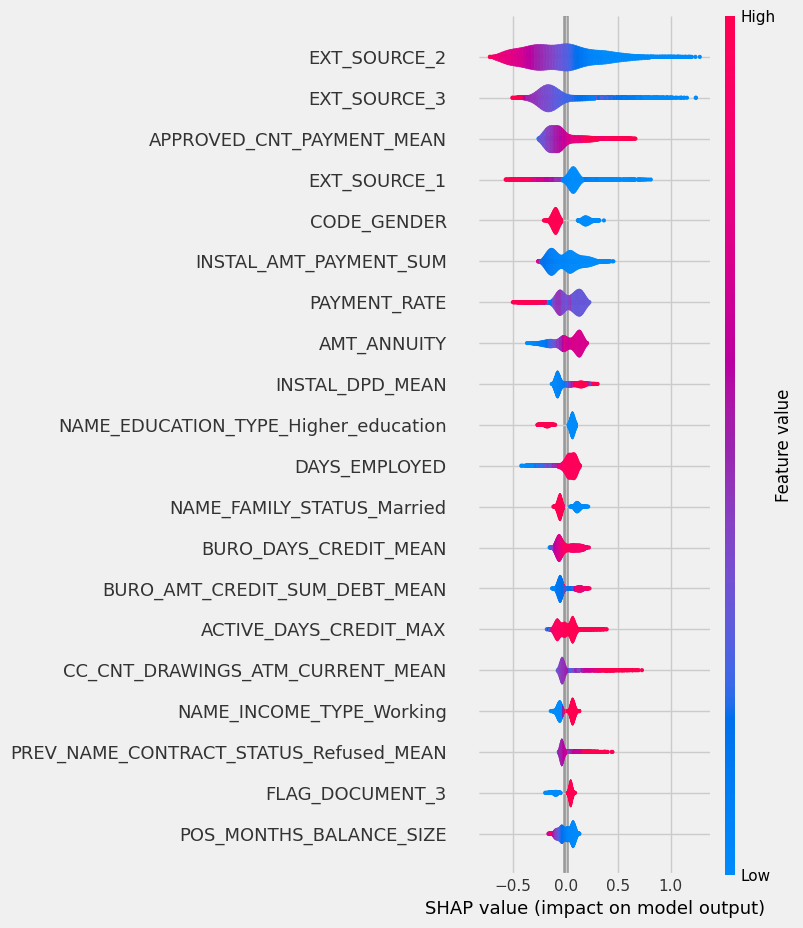

In [129]:
# Récupérer les étapes du pipeline
imputer = final_lgbm.named_steps["imputer"]
lgbm_est = final_lgbm.named_steps["model"]

# Créer un échantillon pour aller plus vite
X_sample = X_test.sample(n=3000, random_state=42)

# Appliquer le même pré-traitement qu’au training
X_sample_imp = imputer.transform(X_sample)

# Créer l’explainer SHAP (nouvelle API)
explainer = shap.TreeExplainer(lgbm_est)

# Calculer les valeurs SHAP
shap_values = explainer(X_sample_imp)

# Summary plot (top 20 features)
shap.summary_plot(
    shap_values,
    X_sample,  # on garde X_sample pour avoir les noms de colonnes
    feature_names=X_sample.columns.tolist(),
    plot_type="violin",
    max_display=20
)


Les 4 premières dominent très largement : `EXT_SOURCE_2`, `EXT_SOURCE_3`, `APPROVED_CNT_PAYMENT_MEAN`, `EXT_SOURCE_1` --> Ces variables ont les plus grands effets absolus sur la prédiction du risque de défaut (target).

- EXT_SOURCE_2 / EXT_SOURCE_3 / EXT_SOURCE_1

Ces trois indicateurs mesurent une évaluation externe du risque de crédit (score normalisé de 0 à 1 dans Home Credit).

Les valeurs faibles (bleu) déplacent le SHAP vers la droite → augmentent le risque.

Les valeurs hautes (rouge) déplacent le SHAP vers la gauche → diminuent le risque.

Interprétation : Un score externe faible est fortement associé à un risque de défaut élevé. Ce sont les variables les plus prédictives et cohérentes économiquement.

- APPROVED_CNT_PAYMENT_MEAN

Moyenne du nombre de paiements effectués sur les prêts précédemment approuvés.

En bleu (faible) → SHAP positif → augmente le risque

En rouge (élevé) → SHAP négatif → diminue le risque.

Interprétation : Les clients ayant un historique de paiements plus régulier / nombreux ont un risque moindre.

- Bar plot global des importances SHAP

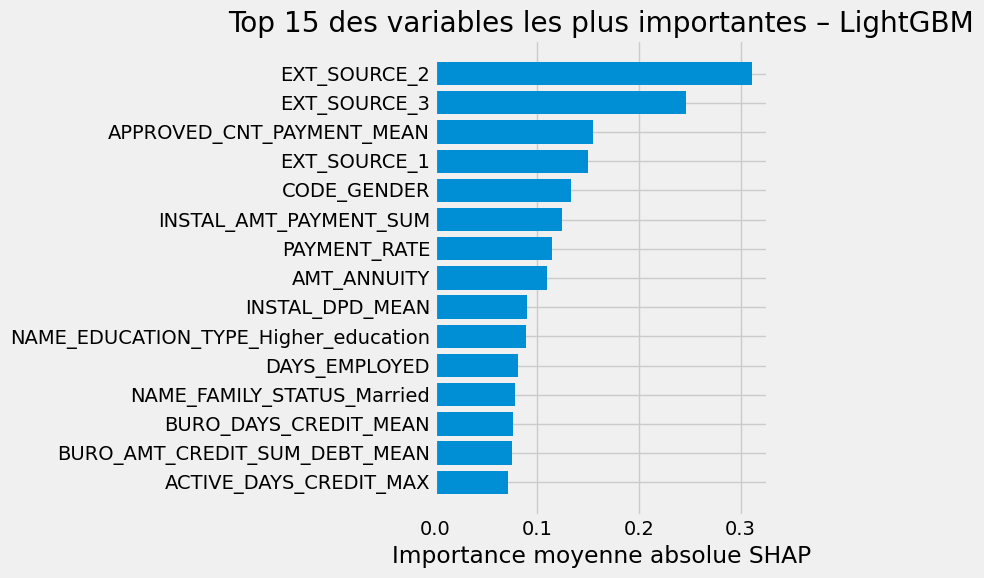

In [ ]:

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

importance_df = pd.DataFrame({
    "feature": X_sample.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)


top_n = 15
top_df = importance_df.head(top_n).iloc[::-1] 

plt.figure(figsize=(8, 6))
plt.barh(top_df["feature"], top_df["mean_abs_shap"])
plt.xlabel("Importance moyenne absolue SHAP")
plt.title("Top 15 des variables les plus importantes – LightGBM")
plt.tight_layout()
plt.show()


L’axe horizontal indique l’importance moyenne absolue des valeurs SHAP.
→ Plus la barre est longue, plus la variable contribue en moyenne aux décisions du modèle.

Ce graphique résume la structure interne du modèle LightGBM : quelles variables influencent le plus le score de risque, toutes observations confondues.

- Force plot pour un client (explication locale)

In [131]:
# Client à haut risque 
# Probabilités de défaut (classe positive)
proba_test = final_lgbm.predict_proba(X_test)[:, 1]

# Index du client le plus risqué
idx_risque = proba_test.argmax()
idx_risque


5434

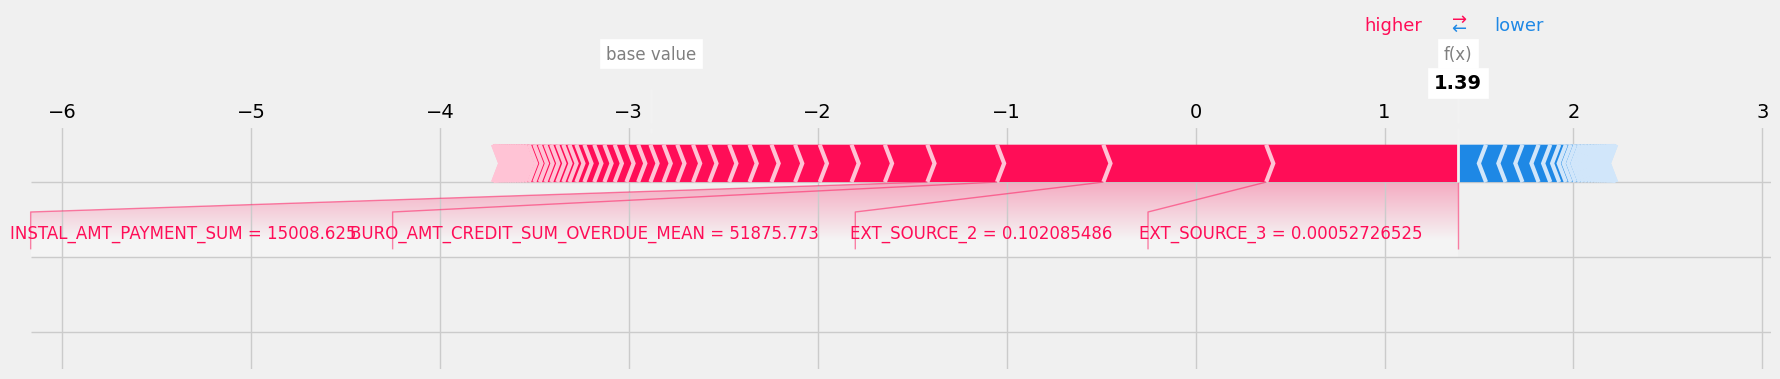

In [132]:
# 1. Extraire le client
x_client = X_test.iloc[[idx_risque]]        # DataFrame 1 ligne
x_client_imp = imputer.transform(x_client)  # version imputée

# 2. SHAP values pour ce client
shap_client = explainer(x_client_imp)       # Explanation, shape (1, n_features)

# 3. Initialiser JS pour affichage interactif (dans notebook)
shap.initjs()

# 4. Force plot
shap.force_plot(
    shap_client.base_values[0],   # valeur de base (log-odds ou proba transformée)
    shap_client.values[0, :],     # contributions SHAP de chaque feature
    x_client,                     # valeurs des features (avec noms de colonnes)
    matplotlib=True               # -> fig statique (pratique pour le rapport)
)


Lecture du graphe : 
- Le point de départ (“base value”) correspond à la prédiction moyenne du modèle, autrement dit la probabilité moyenne de défaut sur l’ensemble du dataset.
- Les flèches rouges poussent la prédiction vers un risque plus élevé (augmentation du score de défaut).
- Les flèches bleues la poussent vers un risque plus faible (réduction du score).
- La valeur finale f(x) = 1.39 (ou ton score LightGBM) représente donc une prédiction plutôt au-dessus du risque moyen, donc un client risqué.

Les plus fortes contributions à la hausse du risque sont :
- `INSTAL_AMT_PAYMENT_SUM` = 15008.62 → Montant total des paiements faibles ou irréguliers, perçu comme un comportement risqué.
- `BURO_AMT_CREDIT_SUM_OVERDUE_MEAN` = 51875.77 → Montant moyen des crédits en retard important, ce qui renforce le risque.
- `EXT_SOURCE_2` = 0.10 et EXT_SOURCE_3 = 0.0005 → Scores de solvabilité externes très bas, traduisant une faible probabilité de remboursement selon des sources externes.
Ces variables tirent fortement le score vers la droite (risque élevé), expliquant la prédiction finale du modèle.

Pour ce client, le modèle estime une probabilité de défaut significativement supérieure à la moyenne (score SHAP global positif).
Les variables principales expliquant cette prédiction sont :
- Un montant élevé de crédits en retard (BURO_AMT_CREDIT_SUM_OVERDUE_MEAN),
- Un total de paiements faible (INSTAL_AMT_PAYMENT_SUM),
- Et des scores externes de solvabilité (EXT_SOURCE_2, EXT_SOURCE_3) très bas.

Ces indicateurs convergent vers un profil de client à haut risque de non-remboursement, ce qui justifie la classification comme client “à risque”.

| Type d’analyse | But                                              | Outil SHAP              | Ce que tu as obtenu                                                 |
| -------------- | ------------------------------------------------ | ----------------------- | ------------------------------------------------------------------- |
| **Globale**    | Comprendre comment le modèle raisonne en général | `summary_plot`, barplot | Les variables clés du modèle (`EXT_SOURCE_2`, `EXT_SOURCE_3`, etc.) |
| **Locale**     | Expliquer la prédiction d’un cas individuel      | `force_plot`            | Les facteurs de risque spécifiques d’un client à haut risque        |


#### **3.9. Data Drift (Evidently)**

In [ ]:
# Choisis le meilleur des deux (souvent LightGBM chez toi)
final_lgbm = rs_lgbm.best_estimator_

with mlflow.start_run(run_name="Final — LightGBM (best from RS)"):
    # ⚠️ Pas besoin de refit ici, evaluate_on_test fait déjà un .fit()
    # final_lgbm.fit(X_train, y_train)

    # évalue une dernière fois sur le vrai test
    metrics_final, fitted_final, proba_final, y_pred_final = evaluate_on_test(
        final_lgbm, X_train, y_train, X_test, y_test
    )

    # log des métriques
    mlflow.log_metrics(_mlflow_safe_metrics(metrics_final))

    # (optionnel mais sympa) : courbes + matrice de confusion
    _log_plots_as_artifacts(
        y_true=y_test,
        y_proba=proba_final,
        y_pred=y_pred_final,
        prefix="LGBM_final"
    )

    # log du modèle final
    signature = infer_signature(X_train, fitted_final.predict_proba(X_train))
    mlflow.sklearn.log_model(fitted_final, "model", signature=signature)

metrics_final

[LightGBM] [Info] Number of positive: 19860, number of negative: 226145
[LightGBM] [Info] Total Bins 8533
[LightGBM] [Info] Number of data points in the train set: 246005, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

{'rocauc': 0.7826909704400727,
 'average_precision': 0.27808870583497775,
 'accuracy': 0.727228382816819,
 'precision': 0.18451840376088466,
 'recall': 0.695669687814703,
 'f1': 0.2916737037662557,
 'business_gain_test': -26921.0,
 'best_threshold_train': 0.08406480701683873,
 'business_gain_train_at_best_thr': -99896.0}

But : comparer train vs test (features uniquement).

In [ ]:
DATA_DIR = "Data"
app_train = pd.read_csv(f"{DATA_DIR}/application_train.csv")
app_test  = pd.read_csv(f"{DATA_DIR}/application_test.csv")


In [ ]:
# Séparer la cible et ne garder que les features
ref = app_train.drop(columns=[c for c in ["TARGET"] if c in app_train.columns]).copy()
cur = app_test.copy()

In [ ]:
# Harmoniser les schémas (mêmes colonnes & types)
# Ajouter les colonnes manquantes côté test
for col in ref.columns:
    if col not in cur.columns:
        cur[col] = np.nan
# Supprimer côté test ce qui n’existe pas côté train
extra_cols = [c for c in cur.columns if c not in ref.columns]
cur = cur.drop(columns=extra_cols)

# Réordonner pour correspondre exactement au train
cur = cur[ref.columns]

# Forcer des types compatibles (option simple : laisser pandas inférer + laisser Evidently gérer)
for c in ref.columns:
    if ref[c].dtype == bool and c in cur.columns:
        cur[c] = cur[c].astype("boolean")  # dtype nullable compatible

In [ ]:
# Construire le rapport Evidently (preset complet de drift)
report = Report(metrics=[
    DataDriftPreset(),          # vue d'ensemble (KS test, PSI, etc.)
    DatasetDriftMetric(),       # métrique globale "dataset drift"
    DataDriftTable(),           # tableau des features avec statut drift / pas drift
])

report.run(reference_data=ref, current_data=cur)

In [ ]:
# Afficher inline (si ton notebook le supporte) et sauvegarder en HTML
report.show(mode="inline")
report.save_html("data_drift_report.html")
print("✅ Rapport Evidently généré : data_drift_report.html")